<a href="https://colab.research.google.com/github/Sshahsavar/COPULA-MODELS/blob/main/Copula_framwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 “All models are wrong, but some are useful.”  George E. P. Box
Standard financial models, such as the Capital Asset Pricing Model (CAPM) and traditional Markowitz mean-variance optimization, rely heavily on linear correlation and the assumption of multivariate normality. Consequently, these models frequently fail to capture the asymmetric, nonlinear dependencies inherent in financial markets, particularly during extreme tail events such as market crashes or violent rallies. This paper investigates the empirical efficacy of Copula-GARCH frameworks in revealing and adapting to changing market regimes. Using daily returns from 10 industry portfolios, we construct Global Minimum Variance (GMV) portfolios optimized via various copula architectures (Normal, Student-t, Clayton, Gumbel, and Rotated Gumbel). The marginal distributions are filtered using an EGARCH(1,1) model, and a dual rolling-window methodology is employed alongside Diebold-Mariano (DM) tests to evaluate dynamic out of sample predictive accuracy against a Constant Conditional Correlation (CCC) benchmark. The results demonstrate that while symmetric copulas offer general outperformance, asymmetric models excel in specific regimes (e.g., the Gumbel copula during the 2020 V-shaped recovery). Furthermore, we identify a “short-selling paradox” during the 2008 Global Financial Crisis, illustrating how highly accurate lower tail dependence models can inadvertently trigger variance maximizing traps in unconstrained optimization scenarios. Ultimately, we propose that the comparative success and intentional failure of specific copula architectures can be leveraged as a powerful diagnostic tool to reverse-engineer and identify underlying market conditions.


# Introduction

**When Do Standard Models Fail?**

Standard financial models, such as CAPM and traditional Markowitz mean-variance optimization, inherently assume that financial returns follow a multivariate normal distribution where linear correlation is the only measure of dependency. These standard models fail when financial returns exhibit heavy tails, volatility clustering, and the tendency to crash simultaneously during severe market downturns. Consequently, traditional frameworks systematically under-predict extreme risk, leaving portfolios vulnerable to asymmetric market dependencies.

## Pearson Correlation and the Joint Distribution

Pearson correlation ($\rho$) is the traditional metric that measures the primary direction and linear strength of the connection between two variables. Mathematically, the population Pearson correlation coefficient is calculated as the covariance of two variables divided by the product of their standard deviations:$$\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y}$$How it reflects the joint distribution?
In standard models, Pearson correlation perfectly defines the dependence structure if and only if the joint distribution is assumed to be an elliptical, normal distribution. It assumes asymptotic independence in the joint tails, meaning it operates under the assumption that extreme joint events (like simultaneous market crashes) are unlikely to occur.




In [ ]:

# HIDE_CELL

# @title 📂🔧 Load and Cleaning the Data

from google.colab import userdata
file_path1 = userdata.get('10_Industry_Portfolios_Daily')
file_path2 = userdata.get('F-F_Research_Data_Factors_daily')

from google.colab import drive
drive.mount('/content/drive')


import pandas as pd
import io

def split_returns_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Find the exact row number (0-indexed) where the 'Equal Weighted' section starts
    split_row_idx = -1
    for i, line in enumerate(lines):
        if "Average Equal Weighted Returns -- Daily" in line:
            split_row_idx = i
            break

    if split_row_idx == -1:
        raise ValueError("Could not find 'Average Equal Weighted Returns -- Daily' marker in the file.")

    # For Fama-French data, the Value Weighted section usually starts after a few metadata lines.
    # A common pattern is that the header for the value-weighted data is around line 10 (0-indexed 9).
    # The error 'Expected 1 fields in line 10, saw 11' strongly suggests line 10 is indeed the header.
    vw_header_line_num = 9 # 0-indexed line number where the VW header is located

    # Read the Value Weighted Returns (Top Part)
    # Skip lines before the header (vw_header_line_num lines) and read up to the split marker.
    # The 'header=0' means the first line after skipping is the header.
    # 'nrows' should be the number of data rows + 1 for the header, after skipping initial lines.
    df_value_weighted = pd.read_csv(
        file_path,
        skiprows=vw_header_line_num,
        nrows=split_row_idx - vw_header_line_num - 2 ,
        header=0
    )

    # Clean up empty rows if any exist at the bottom of the value-weighted section
    df_value_weighted.dropna(how='all', inplace=True)

    # Read the Equal Weighted Returns (Bottom Part)
    # Skip all lines up to and including the 'Average Equal Weighted Returns' marker.
    # The header for EW data is usually immediately after this marker.
    df_equal_weighted = pd.read_csv(
        file_path,
        skiprows=split_row_idx + 1, # Skip the marker line itself and all lines before it
        header=0 # The first line after skipping is the header for EW data
    )

    # Clean up empty rows if any exist at the bottom of the equal-weighted section
    df_equal_weighted.dropna(how='all', inplace=True)
    #drop the last line of each data frame
    df_equal_weighted = df_equal_weighted.iloc[:-1]
    df_value_weighted = df_value_weighted.iloc[:-1]
    return df_value_weighted, df_equal_weighted

# --- How to use it ---
df_vw, df_ew = split_returns_file(file_path1)

# i use Value Weighted Data
raw = df_vw.copy()

#changing the Date format to pd formart
raw = raw.rename(columns={'Unnamed: 0': 'Date'})
raw['Date'] = pd.to_datetime(raw['Date'], format='%Y%m%d', errors='coerce')
raw = raw.dropna(subset=['Date'])
display(raw.head())

# adding the Market Risk primume:
#Data source:
#https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html
# Load the CSV, skipping the first 3 rows
df_factors = pd.read_csv(file_path2, skiprows=3)

# Drop the last row
df_factors = df_factors.iloc[:-1]

display(df_factors.head())
display(df_factors.tail())

# Rename 'Unnamed: 0' to 'Date' in df_factors
df_factors = df_factors.rename(columns={'Unnamed: 0': 'Date'})

# Convert the 'Date' column in df_factors to datetime objects
df_factors['Date'] = pd.to_datetime(df_factors['Date'], format='%Y%m%d', errors='coerce')

# Drop any rows where Date conversion failed (if any)
df_factors.dropna(subset=['Date'], inplace=True)

# Merge df_factors and df_vw on the 'Date' column
raw = pd.merge(raw, df_factors, on='Date', how='inner')

columns_to_convert = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other', 'Mkt-RF', 'SMB','HML','RF' ]

for col in columns_to_convert:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

print("Columns converted to numeric:")
print(raw[columns_to_convert].dtypes)

#missing Data

import numpy as np
# Define the values to be considered as missing
missing_values = [-99.99, -999]

# Replace the specified missing values with NaN in the entire DataFrame
raw.replace(missing_values, np.nan, inplace=True)

 # add bussines cycle data
recession_periods = [
    ('1918-08-01', '1919-03-31'),
    ('1920-01-01', '1921-07-31'),
    ('1923-05-01', '1924-07-31'),
    ('1926-10-01', '1927-11-30'),
    ('1929-08-01', '1933-03-31'),
    ('1937-05-01', '1938-06-30'),
    ('1945-02-01', '1945-10-31'),
    ('1948-11-01', '1949-10-31'),
    ('1953-07-01', '1954-05-31'),
    ('1957-08-01', '1958-04-30'),
    ('1960-04-01', '1961-02-28'),
    ('1969-12-01', '1970-11-30'),
    ('1973-11-01', '1975-03-31'),
    ('1980-01-01', '1980-07-31'),
    ('1981-07-01', '1982-11-30'),
    ('1990-07-01', '1991-03-31'),
    ('2001-03-01', '2001-11-30'),
    ('2007-12-01', '2009-06-30'),
    ('2020-02-01', '2020-04-30')
]
raw["Recession"] = 0
for start, end in recession_periods:
    mask = (raw['Date'] >= start) & (raw['Date'] <= end)
    raw.loc[mask, 'Recession'] = 1



Mounted at /content/drive


,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1926-07-01,0.02,-0.28,-0.23,0.57,-0.21,-0.02,-0.01,0.97,0.61,0.20
1,1926-07-02,0.29,1.07,0.81,0.64,0.36,0.26,0.01,0.13,0.47,0.10
2,1926-07-06,0.24,0.72,0.22,0.17,0.47,0.17,-0.23,0.23,0.73,-0.18
3,1926-07-07,0.27,0.06,0.23,-0.04,-0.10,0.32,-0.59,0.33,0.17,0.16
4,1926-07-08,0.69,0.05,0.15,0.12,0.35,0.40,-0.36,0.91,-0.20,0.39


,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,19260701,0.09,-0.25,-0.27,0.01
1,19260702,0.45,-0.33,-0.06,0.01
2,19260706,0.17,0.30,-0.39,0.01
3,19260707,0.09,-0.58,0.02,0.01
4,19260708,0.22,-0.38,0.19,0.01


,Unnamed: 0,Mkt-RF,SMB,HML,RF
26228,20260424,0.70,-0.34,-0.28,0.01
26229,20260427,0.10,-0.19,0.62,0.01
26230,20260428,-0.57,-0.44,0.88,0.01
26231,20260429,-0.13,-1.48,0.53,0.01
26232,20260430,1.13,0.98,-0.71,0.01


Columns converted to numeric:
NoDur     float64
Durbl     float64
Manuf     float64
Enrgy     float64
HiTec     float64
Telcm     float64
Shops     float64
Hlth      float64
Utils     float64
Other     float64
Mkt-RF    float64
SMB       float64
HML       float64
RF        float64
dtype: object


In [ ]:
# HIDE_CELL
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

try:
    import dataframe_image as dfi
except ImportError:
    !pip install dataframe_image --quiet
    import dataframe_image as dfi

start_date_2007_2017 = '2007-01-01'
end_date_2007_2017 = '2017-01-01'
df_2007_2017 = raw[(raw['Date'] >= start_date_2007_2017) & (raw['Date'] <= end_date_2007_2017)].copy()
asset_list = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other' ]

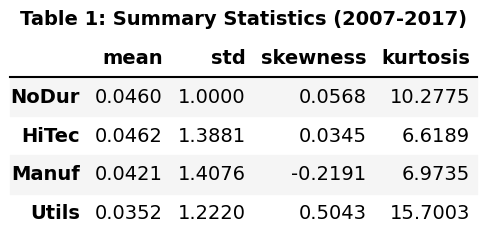

In [ ]:
# @title 📊 Summary Statistics & Table Export

# Define the requested assets
assets_to_analyze = ['NoDur', 'HiTec', 'Manuf', 'Utils']

# 1. Calculate Summary Statistics
summary_stats = df_2007_2017[assets_to_analyze].describe().T
summary_stats['skewness'] = df_2007_2017[assets_to_analyze].skew()
summary_stats['kurtosis'] = df_2007_2017[assets_to_analyze].kurt()

# 2. Style the table
final_table = summary_stats[['mean', 'std', 'skewness', 'kurtosis']]
styled_table = final_table.style.set_caption("Table 1: Summary Statistics (2007-2017)") \
    .format("{:.4f}") \
    .set_properties(**{'text-align': 'center', 'font-family': 'sans-serif', 'border': '1px solid #dee2e6'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#212529'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])

# 3. Export to PNG using matplotlib engine
output_png = "summary_statistics_table.png"
dfi.export(styled_table, output_png, table_conversion="matplotlib")

# 4. Display the results
display(Image(filename=output_png))

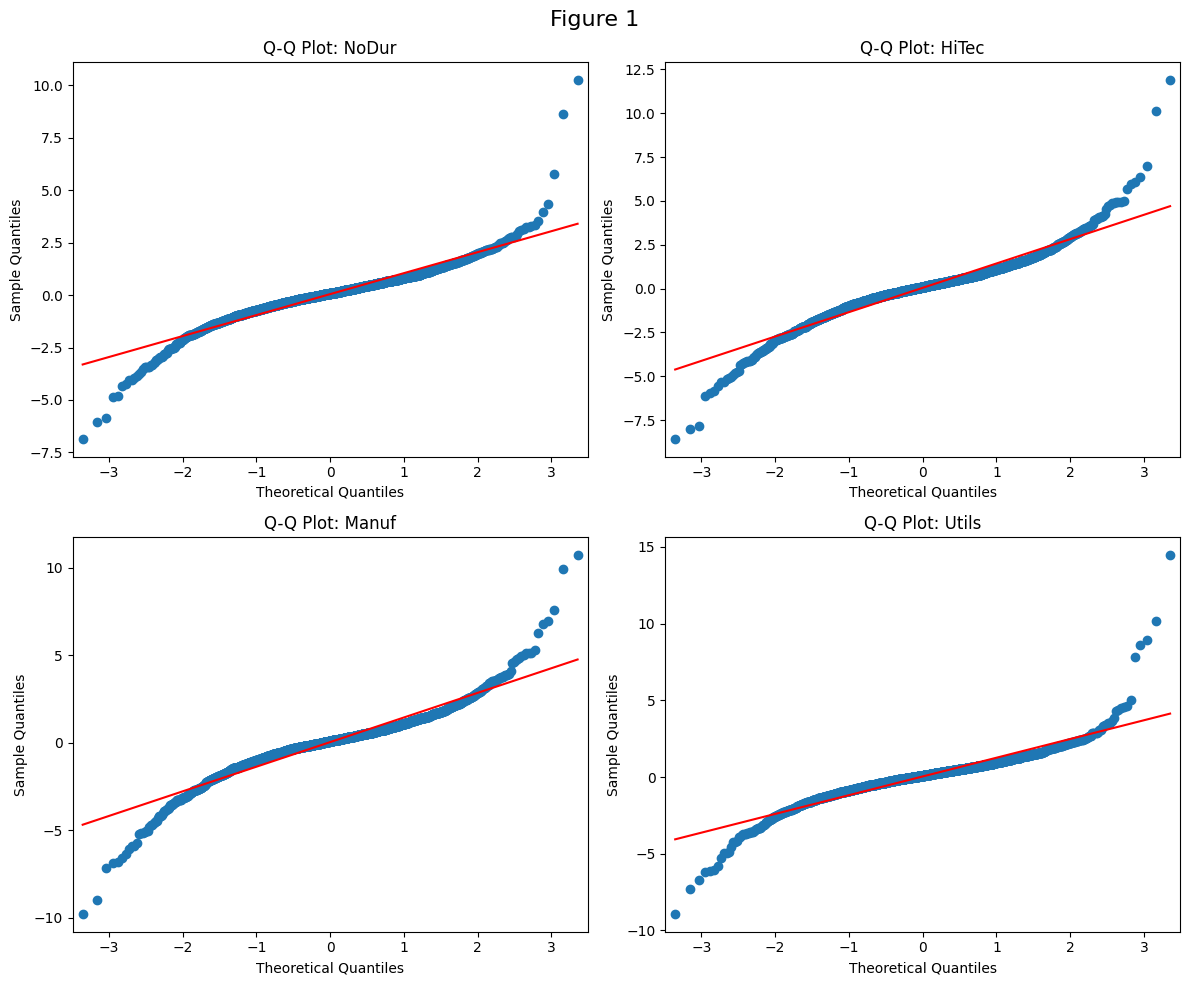

In [ ]:
# 2. Plot Q-Q Plots
plt.figure(figsize=(12, 10))
for i, asset in enumerate(assets_to_analyze):
    ax = plt.subplot(2, 2, i + 1)
    sm.qqplot(df_2007_2017[asset].dropna(), line='s', ax=ax)
    ax.set_title(f'Q-Q Plot: {asset}')

# Add figure title
plt.suptitle('Figure 1', fontsize=16)
plt.tight_layout()
plt.show()

Table 1 and the plots in figure 1 show the distribution of returns of 4 industiries between 2007 and 2017.
The returns is t distributed and have heivy tail.

## Rank Correlation
Rank correlation focuses on the ordinal, monotonic relationship between variables rather than their strict linear proportionality.
By studying this specific bivariate system, a researcher can analyze and test distinct joint behaviors, such as how the two move together linearly or monotonically.Unlike Pearson correlation—which measures raw values and assumes elliptical joint distributions—rank metrics evaluate dependence based purely on the relative ranking of the data points.
Because rank correlation is invariant to strictly increasing monotonic transformations, it depends only on the copula itself, completely isolating the dependence structure from the individual marginal distributions.There are two primary mathematical measures of rank correlation used in copula modeling:

**A. Spearman's Rho ($\rho_s$):**

Spearman's Rho is essentially the standard Pearson correlation coefficient applied directly to the ranked variables rather than the raw data. It assesses how well the relationship between two variables can be described using a monotonic function.If all $n$ ranks are distinct integers, it can be computed using the following simplified formula:
$$\rho_s = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

  Where:
  * $d_i$ represents the difference between the ranks of the corresponding variables for observation
  * $i$ (i.e., $d_i = \text{rank}(X_i) - \text{rank}(Y_i)$).$n$ is the total number of observations.
  


**B. Kendall's Tau ($\tau$):**

Kendall's Tau measures the strength of dependence based on the probabilities of observing concordant and discordant pairs. A pair of observations $(X_i, Y_i)$ and $(X_j, Y_j)$ is considered concordant if the ranks for both elements agree (i.e., if $X_i > X_j$ then $Y_i > Y_j$, or if $X_i < X_j$ then $Y_i < Y_j$).

They are discordant if they disagree.The mathematical formula for Kendall's Tau is:

$$\tau = \frac{n_c - n_d}{\frac{1}{2} n(n-1)}$$

Where:
* $n_c$ is the total number of concordant pairs.

* $n_d$ is the total number of discordant pairs.

* $\frac{1}{2}n(n-1)$ is the total possible number of pair combinations in the dataset.

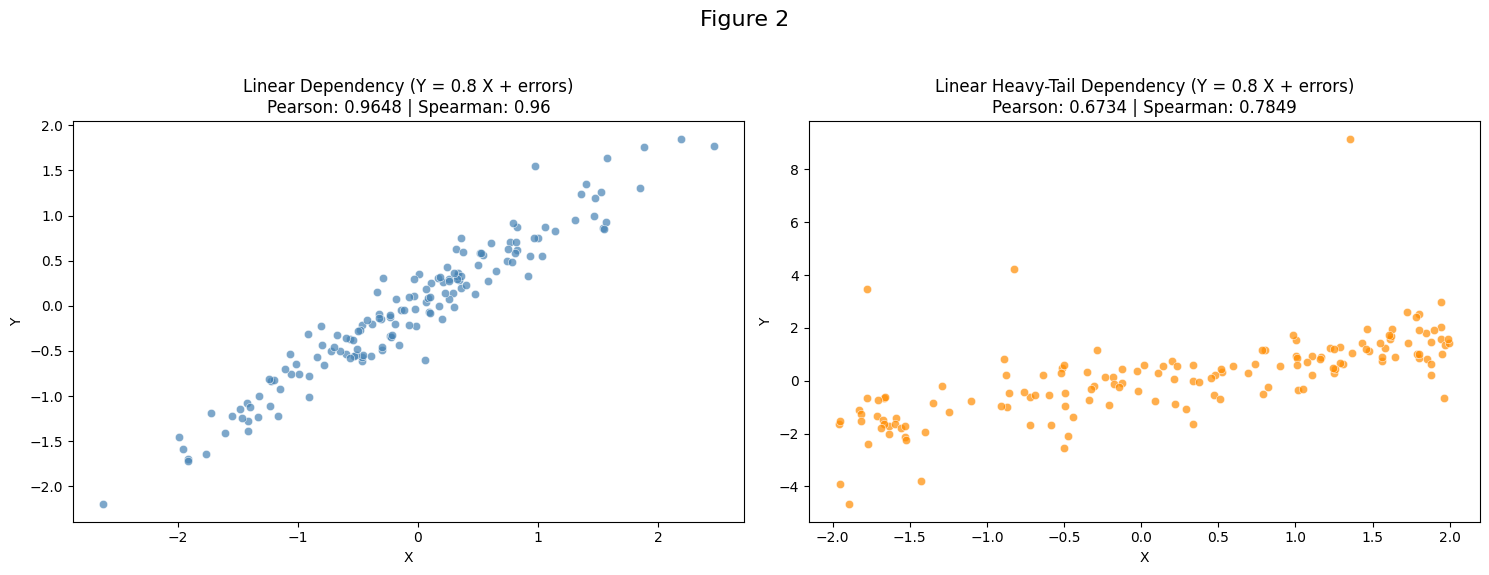

In [ ]:

# Correlation Sensitivity: Linear vs Non-Linear Heavy-Tail

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Generate Data
np.random.seed(42)
n_samples = 150

# Sample 1: Linear Dependency
x_lin = np.random.normal(0, 1, n_samples)
y_lin = 0.8 * x_lin + np.random.normal(0, 0.2, n_samples)

# Sample 2: Linear Dependent with Heavy Tails
x_lin_heavy_tail = np.random.uniform(-2, 2, n_samples)
y_lin_heavy_tail = 0.8 * x_lin_heavy_tail  + stats.t.rvs(df=2, size=n_samples)* 0.5

# Sample 2: Non-Linear Dependent with Heavy Tails

x_nonlin = np.random.uniform(-2, 2, n_samples)
#y_nonlin = (x_nonlin ** 3) + stats.t.rvs(df=2, size=n_samples) * 0.5


# 2. Calculate Stats
def get_stats(x, y):
    p_rho, _ = stats.pearsonr(x, y)
    s_rho, _ = stats.spearmanr(x, y)
    return round(p_rho, 4), round(s_rho, 4)

p_lin, s_lin = get_stats(x_lin, y_lin)
p_non, s_non = get_stats(x_lin_heavy_tail, y_lin_heavy_tail)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Linear
sns.scatterplot(x=x_lin, y=y_lin, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title(f'Linear Dependency (Y = 0.8 X + errors)\nPearson: {p_lin} | Spearman: {s_lin}')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Plot 2: Linear Heavy tail
sns.scatterplot(x=x_lin_heavy_tail, y=y_lin_heavy_tail, ax=axes[1], color='darkorange', alpha=0.7)
axes[1].set_title(f'Linear Heavy-Tail Dependency (Y = 0.8 X + errors)\nPearson: {p_non} | Spearman: {s_non}')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# Add figure title
plt.suptitle('Figure 2', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The figure 2 shows the differnce of pearson correlation and spearman correlation with data with normal distribution and heavy tail.
The eqaution between y and x is same in both figures, but the blue figure x is normally distributed and in orege one the x has heavy tails.
The correlation between y and x should be close to 1. when the data is normally distributed the pearson and spearman correlation has same performance but when the data has heavy tail the spearman works better.

## Sklar's Theorem
Sklar's Theorem is the fundamental mathematical mechanism that allows copulas to work. It proves that any joint probability distribution can be decomposed into its individual marginal distributions and a central copula function.The Math: According to Sklar's Theorem, if the individual continuous densities exist, the total joint probability density function (pdf) for any two assets ($y_1$ and $y_2$) is calculated as:$$f(y_{1}, y_{2}) = c\big(F_{1}(y_{1}), F_{2}(y_{2})\big) \times f_{1}(y_{1}) \times f_{2}(y_{2})$$Reflecting the Joint Distribution: The theorem reflects the joint distribution by separating the marginal behaviors—represented by the univariate densities $f_{1}(y_{1})$ and $f_{2}(y_{2})$—from the dependence structure. The marginal cumulative distribution functions ($F_{1}(y_{1})$ and $F_{2}(y_{2})$) transform the raw data into uniform variables ($u_1$ and $u_2$). Finally, the copula density function, $c(u_1, u_2)$, scales and isolates the exact co-movement between the variables.

In [ ]:
# @title 🔔 distrbution:
# HIDE_CELL
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import jarque_bera, nct

def get_distribution_type(returns):
    """
    Analyzes the distribution of a time series,
    runs statistical tests, and compares Normal, Student's t, and Skew-t fits.
    """
    # Clean data
    returns = returns.dropna()


    # FIT THE DISTRIBUTIONS
    print("\n📐 CALCULATING FIT ERRORS (SSE)...")
    y, x_bins = np.histogram(returns, bins=100, density=True)
    x_mid = (x_bins + np.roll(x_bins, -1))[:-1] / 2.0

    # Normal Fit
    norm_params = stats.norm.fit(returns)
    norm_sse = np.sum((y - stats.norm.pdf(x_mid, *norm_params))**2)

    # Student's t Fit
    t_params = stats.t.fit(returns)
    t_sse = np.sum((y - stats.t.pdf(x_mid, *t_params))**2)

    # Skew-Student's t Fit (Using Non-central t as proxy for comparison)
    # Note: 'nct' is a good proxy for skewness + heavy tails
    st_params = nct.fit(returns)
    st_sse = np.sum((y - nct.pdf(x_mid, *st_params))**2)

    # DETERMINE WINNER
    print("-" * 50)
    results = {'normal': norm_sse, 't': t_sse, 'skewt': st_sse}
    best_dist = min(results, key=results.get)

    return best_dist

## Review on Copula models

based on the Sklar's Theorem a joint distribution can be completely separated into two distinct parts:

1.The individual behavior of each asset (the marginal distributions).

2.The relationship between them (the copula).

to calculate the marginal distribution of each asset useing the GARCH models for each assets and canculate the residuals for the copula part.
To the copula functions use the uniform distributions, so the residuals must convert to the uniform[0,1] to useed in copula models.


### creating uniform distributions:



In the study of joint probability and dependence modeling, the **Uniform distribution** serves as the universal currency. Copulas are functions that join multivariate distribution functions to their one-dimensional marginal distributions. For a copula to act as a pure measure of dependence, it strips away the unique scales, shapes, and locations of individual variables. This isolation of the dependency structure relies entirely on transforming the variables into a standard environment: the **Continuous Uniform distribution** on the interval $[0, 1]$, denoted as $U(0, 1)$.

---

#### 1. The Core Concept: What is a Uniform Distribution?

A continuous random variable $U$ is said to follow a standard uniform distribution on the interval $[0, 1]$ if its probability density is spread completely evenly across this range. It carries a fundamental property: **equal-length intervals have equal probabilities**.

* **The Probability Density Function (PDF):** The height of the density function is constant, forming a flat geometric block.

$$f(u) = \begin{cases} 1 & \text{for } 0 \le u \le 1 \\ 0 & \text{otherwise} \end{cases}$$


* **The Cumulative Distribution Function (CDF):** Because the density is uniform, the accumulated probability grows at a constant, linear rate from 0 to 1.

$$F(u) = \begin{cases} 0 & \text{for } u < 0 \\ u & \text{for } 0 \le u \le 1 \\ 1 & \text{for } u > 1 \end{cases}$$



---

#### 2. The Two Paths to Uniformity

In empirical research, econometrics, and risk management, we rarely begin with uniform data. Instead, we observe raw data—such as asset returns, climate patterns, or insurance losses—which exhibit skewness, heavy tails, or normal distributions.

To bridge the gap between raw data and copula space, we utilize two distinct operational forms of the Probability Integral Transform (PIT) to create uniform margins: The **Parametric** Form and The **Semiparametric (Empirical)** Form.

##### **Form A: The Parametric Approach**

The parametric form relies on the assumption that the raw data follows a known, theoretical probability distribution (such as a Normal, Student's $t$, or GARCH-filtered residual distribution).

If a continuous random variable $Y$ has a known cumulative distribution function $F_Y(y)$, then according to the **Probability Integral Transform**, transforming the variable by its own CDF yields a perfect standard uniform variable:


$$U = F_Y(Y) \sim U(0, 1)$$

* **How it works:** You estimate the parameters of the distribution (e.g., the mean $\mu$ and variance $\sigma^2$ for a Normal distribution) from your data. You then pass your raw data points through that analytical equation. Each raw value is mapped directly to its exact theoretical percentile ranking.
* **Limitation:** If your chosen parametric model does not fit the true underlying data well (misspecification), the resulting transformed variables will fail to be truly uniform, introducing bias into the copula estimation.

##### **Form B: The Semiparametric (Empirical) Approach**

When the true underlying distribution of the data is complex, unknown, or cannot be easily captured by standard mathematical formulas, researchers bypass parametric assumptions entirely using the empirical distribution function (EDF).

For a sample of size $T$, the empirical transform converts data points into uniform margins based purely on their relative sample ranks:


$$U_t = \frac{R_t}{T + 1}$$


Where $R_t$ represents the rank of the data point $Y_t$ (from smallest to largest) within the sample.

* **How it works:** The smallest value in a dataset of 99 observations receives a rank of 1, transforming into $\frac{1}{100} = 0.01$ (the 1st percentile). The division by $T + 1$ rather than $T$ is a technical adjustment designed to bound the output strictly inside the open interval $(0, 1)$, preventing boundary errors (such as an evaluation at exactly 1) during copula maximum likelihood estimation.
* **Advantage:** It is completely robust to model misspecification because it forces the margins to be uniform by definition, preserving the raw, distribution-free dependency structure of the data.

In [ ]:
# HIDE_CELL

# @title 🧮 Residual

try:
    from arch import arch_model
except ImportError:
    !pip install arch --quiet
    from arch import arch_model

# Iterate through each asset in the asset list
for asset in asset_list:

    # Prepare the returns data
    returns = df_2007_2017[asset]

    # Handle scaling if variance is low to help optimizer convergence
    scale_factor = 1.0
    if returns.var() < 0.1:
        scale_factor = 100.0

    scaled_returns = returns * scale_factor

    # Initialize and fit EGARCH(1,1) for all assets
    # We use a Student's t distribution as the default for financial returns
    model = arch_model(
        scaled_returns,
        vol='EGARCH',
        p=1,
        o=1,
        q=1,
        dist='studentst',
        mean='Constant'
    )

    res = model.fit(disp='off', show_warning=False)

    # Calculate standardized residuals: (epsilon_t / sigma_t)
    # We store them in the dataframe for use in the Copula section
    df_2007_2017[f'{asset}_resid'] = res.resid / res.conditional_volatility


In [ ]:
# HIDE_CELL

# @title 🧮 PIT prametric


import numpy as np
from scipy.stats import t

def calculate_u_parametric(df, asset_name, residual_col):
    """
    Calculates parametric uniform probabilities (U_t) from residuals using a t-distribution.
    Formula: U_t = F_t(resid_t ; theta)
    """
    residuals = df[residual_col].dropna().values

    # 1. Fit the t-distribution to your data to find the parameters
    # Returns degrees of freedom (df_fit), location (loc), and scale (scale)
    df_fit, loc, scale = t.fit(residuals)

    # 2. Pass the data through the fitted Cumulative Distribution Function (CDF)
    u_col_name = f'uparam_{asset_name}'
    df[u_col_name] = t.cdf(df[residual_col], df_fit, loc, scale)

    return df

# Example usage for all assets in your list:
for asset in asset_list:
    resid_col = f'{asset}_resid'
    if resid_col in df_2007_2017.columns:
        df_2007_2017 = calculate_u_parametric(df_2007_2017, asset, resid_col)


In [ ]:
# @title 🧮 PIT emprical

# HIDE_CELL

from scipy.stats import rankdata

def calculate_u_empirical(df, asset_name, residual_col):
    """
    Calculates empirical uniform probabilities (U_t) from residuals.
    Formula: U_t = Rank(resid_t) / (T + 1)
    """
    residuals = df[residual_col].values
    T = len(residuals)

    # rankdata assigns rank 1 to the smallest value, T to the largest
    ranks = rankdata(residuals)

    # Convert ranks to uniform probabilities [0, 1]
    # Renamed to u_emp_{asset_name} for clarity vs uparam_{asset_name}
    u_col_name = f'u_emp_{asset_name}'
    df[u_col_name] = ranks / (T + 1)

    return df

# Example usage for all assets in your list:
for asset in asset_list:
    resid_col = f'{asset}_resid'
    if resid_col in df_2007_2017.columns:
        df_2007_2017 = calculate_u_empirical(df_2007_2017, asset, resid_col)


### Copula models: Dual Asset

In this section, I use data from the Durable and High-Tech industries to explore various types of parametric copulas and demonstrate the different paths followed by each copula model.

A parametric copula is a specific mathematical function chosen from a established "family" of copulas to model the dependence between variables. Unlike non-parametric (empirical) approaches that just look at raw data bins, parametric copulas use an exact algebraic equation controlled by one or more parameters (such as $\theta$, $\rho$, or $\nu$).These parameters act as a "dial." By estimating the correct parameter from the data (usually via Maximum Likelihood Estimation), you dictate the exact strength, shape, and tail behavior of the joint distribution.Mathematically, parametric copulas are broadly divided into two main classes: Elliptical Copulas and Archimedean Copulas.

* In this part i use the Copula library in pyhton which is use Maximum loikelihood to estimate the Copula paramaters.
* the other approch to estimate the Copula prameters is create bootstrap samples and fit the copulas and find the standard diviation of parameters.

#### 1. Elliptical Copulas
Elliptical copulas are extracted from standard multivariate distributions using Sklar's Theorem. They are highly effective for modeling symmetric dependence.

#####  A. Normal Copula
Summary: The Normal (Gaussian) copula assumes symmetric, linear dependence between variables. It has zero tail dependence, meaning it assumes extreme events (market crashes or massive booms) are independent.Equation:$$C(u,v;\rho) = \Phi_\rho(\Phi^{-1}(u), \Phi^{-1}(v))$$where $\Phi_\rho$ is the bivariate normal CDF with correlation $\rho$, and $\Phi^{-1}$ is the inverse standard normal CDF.

In [ ]:
# HIDE_CELL

# @title 🧮 Copula normal

try:
    import copulae
except ImportError:
  !pip install copulae

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.2
    Uninstalling wrapt-2.2.2:
      Successfully uninstalled wrapt-2.2.2


Normal Copula Parameter (Rho):
[0.72728425]

Summary of fitted Copula:
Gaussian Copula Summary
Gaussian Copula with 2 dimensions


Parameters
--------------------------------------------------------------------------------
 Correlation Matrix 
1.000000 0.727284
0.727284 1.000000



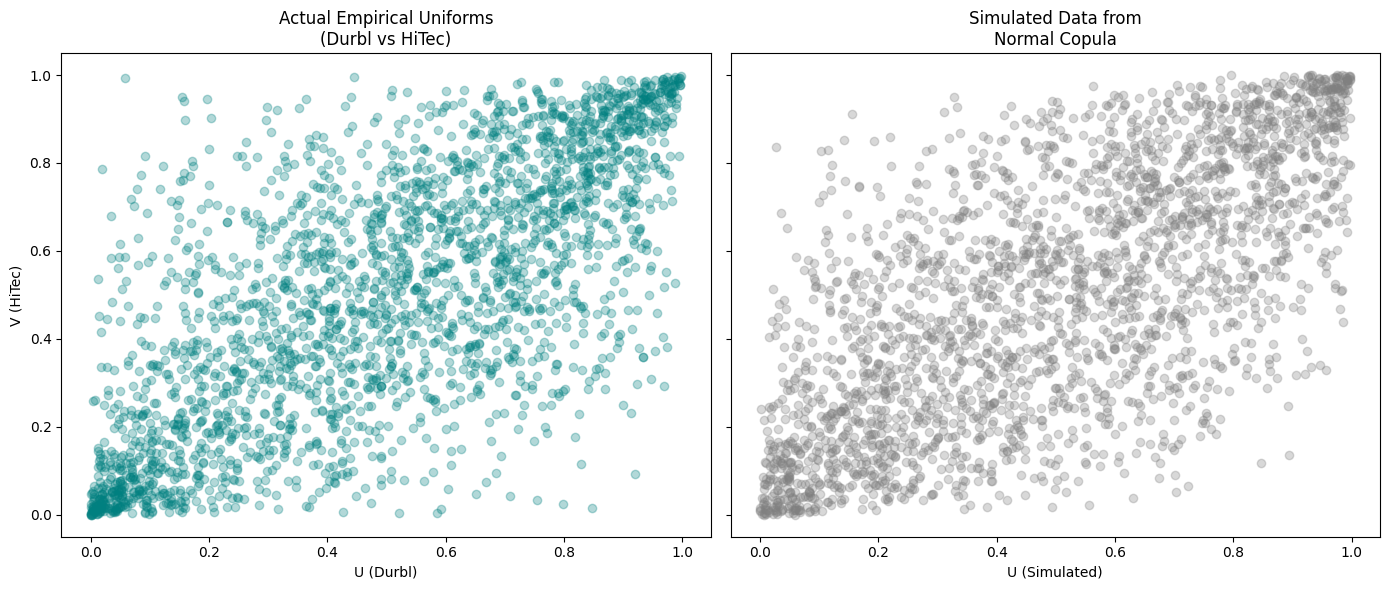

In [ ]:
# HIDE_CELL

from copulae import NormalCopula
import numpy as np
import matplotlib.pyplot as plt

# 1. Selecting the parametric uniform transformed data
u = df_2007_2017['uparam_NoDur'].values
v = df_2007_2017['uparam_HiTec'].values
# Prepare the bivariate data matrix
data = np.column_stack((u, v))

# 2. Initialize and fit the Normal (Gaussian) Copula
norm_cop = NormalCopula(dim=2)
norm_cop.fit(data)

print("Normal Copula Parameter (Rho):")
print(norm_cop.params)
print("\nSummary of fitted Copula:")
print(norm_cop.summary())

# 3. Visualization: Simulate data from the fitted Normal copula
sim_data_norm = norm_cop.random(len(data))

# 4. Plotting side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Actual Data
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Empirical Uniforms\n(Durbl vs HiTec)')
ax[0].set_xlabel('U (Durbl)')
ax[0].set_ylabel('V (HiTec)')

# Simulated Data (Normal)
ax[1].scatter(sim_data_norm[:, 0], sim_data_norm[:, 1], alpha=0.3, color='gray')
ax[1].set_title('Simulated Data from\nNormal Copula')
ax[1].set_xlabel('U (Simulated)')

plt.tight_layout()
plt.show()

##### B. Student's t-Copula
Summary: Unlike the Normal copula, the Student's t-copula captures **tail dependence**. This means it accounts for the tendency of markets to crash (or boom) together more frequently than a normal distribution would predict.

Equation:
$$C(u,v; \rho, \nu) = t_{\rho, \nu}(t_\nu^{-1}(u), t_\nu^{-1}(v))$$
where $\nu$ represents the degrees of freedom (lower $\nu$ = heavier tails/stronger joint extremes).

Student's t-Copula Parameters:
Correlation (Rho): 0.7317
Degrees of Freedom (Nu): 5.4633


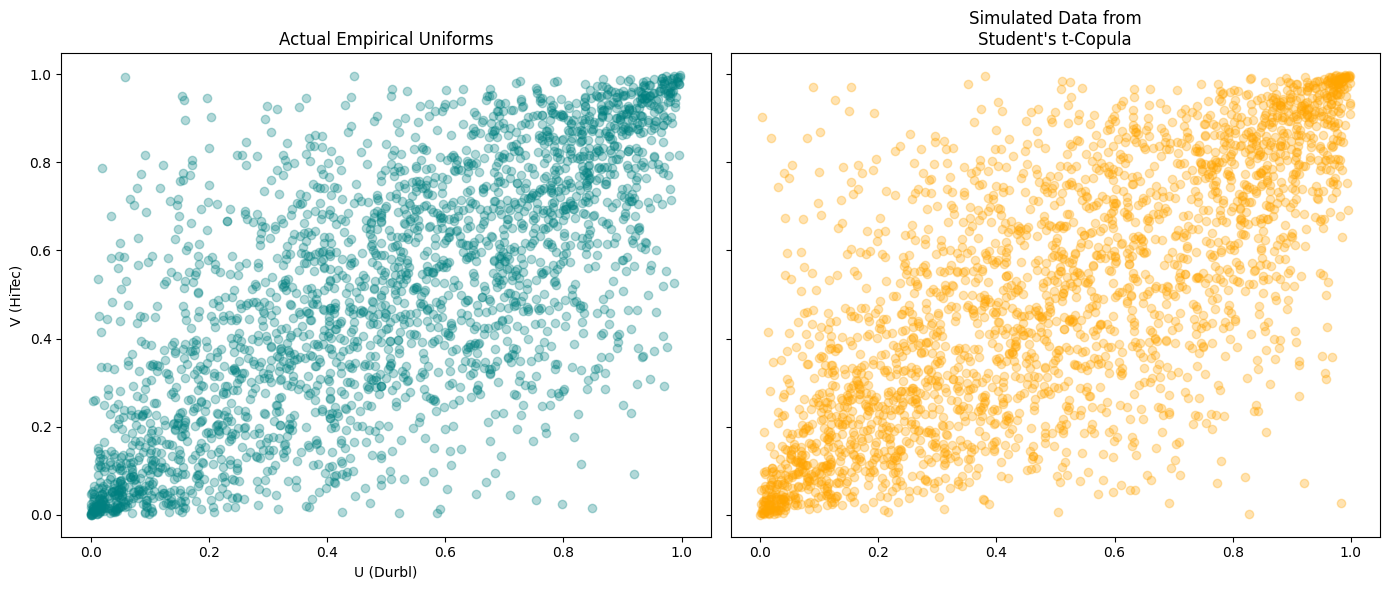

In [ ]:
# HIDE_CELL

# @title 🧮 T-Copula


from copulae import StudentCopula
import matplotlib.pyplot as plt

# 1. Initialize and fit the Student's t-Copula
t_cop = StudentCopula(dim=2)
t_cop.fit(data)

print("Student's t-Copula Parameters:")
print(f"Correlation (Rho): {t_cop.params.rho[0]:.4f}")
print(f"Degrees of Freedom (Nu): {t_cop.params.df:.4f}")

# 2. Visualization: Simulate data
sim_data_t = t_cop.random(len(data))

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Empirical Uniforms')
ax[0].set_xlabel('U (Durbl)')
ax[0].set_ylabel('V (HiTec)')
ax[1].scatter(sim_data_t[:, 0], sim_data_t[:, 1], alpha=0.3, color='orange')
ax[1].set_title("Simulated Data from\nStudent's t-Copula")
plt.tight_layout()
plt.show()

#### 2. Archimedean Copulas
Unlike Elliptical copulas, Archimedean copulas are not derived from multivariate distributions. Instead, they are built algebraically using a generator function, denoted as $\phi(t)$.The Foundational Math: An Archimedean copula is constructed by plugging the uniform variables into the generator function, summing them, and then taking the pseudo-inverse:$$C(u, v) = \phi^{[-1]}(\phi(u) + \phi(v))$$Because they are built this way, they are highly flexible and can capture asymmetric dependence (e.g., assets crash together, but don't boom together).

##### A. Clayton Copula
Summary: The Clayton copula is asymmetric and sensitive to **lower-tail dependence**. It is widely used in finance because it models the behavior where assets correlate more strongly during market downturns than during upturns.

Equation:
$$C(u,v; \theta) = (u^{-\theta} + v^{-\theta} - 1)^{-1/\theta}$$
where $\theta > 0$ represents the dependence strength.

Clayton Copula Parameter (Theta): 1.5561


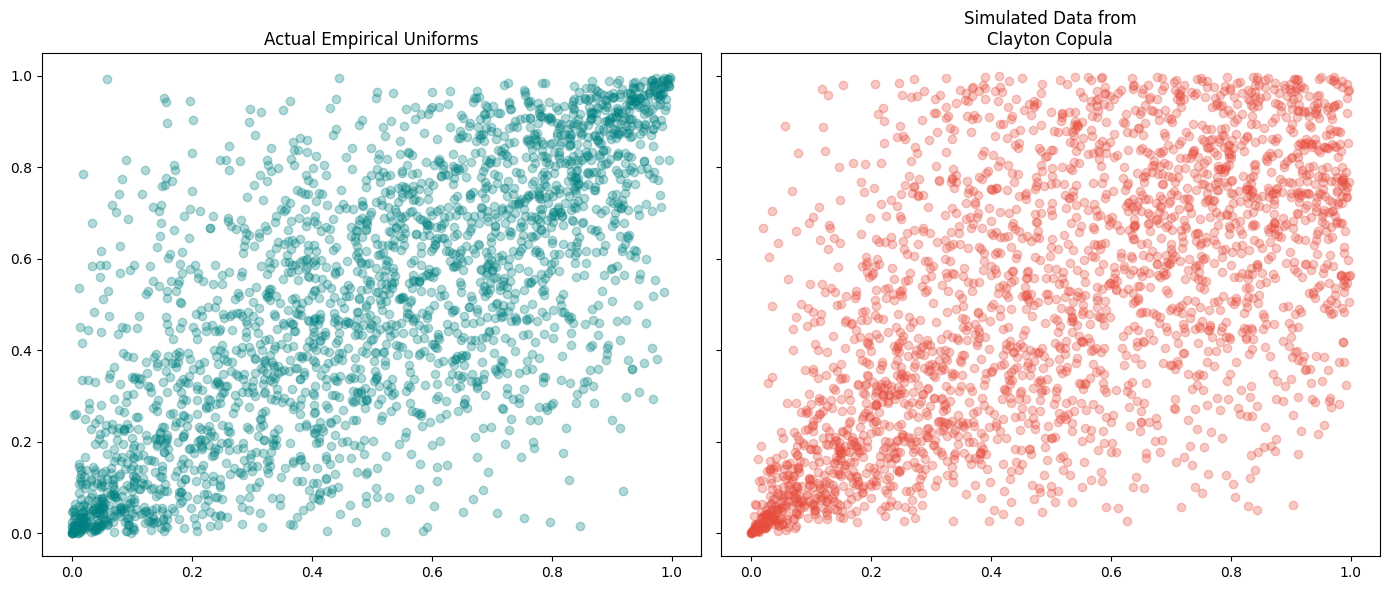

In [ ]:
# HIDE_CELL

# @title 🧮 Clayton


from copulae import ClaytonCopula
import matplotlib.pyplot as plt

# 1. Initialize and fit the Clayton Copula
clayton_cop = ClaytonCopula(dim=2)
clayton_cop.fit(data)

print(f"Clayton Copula Parameter (Theta): {clayton_cop.params:.4f}")

# 2. Visualization: Simulate data
sim_data_clayton = clayton_cop.random(len(data))

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Empirical Uniforms')
ax[1].scatter(sim_data_clayton[:, 0], sim_data_clayton[:, 1], alpha=0.3, color='#e74c3c')
ax[1].set_title('Simulated Data from\nClayton Copula')
plt.tight_layout()
plt.show()

##### B. Gumbel Copula
Summary: The Gumbel copula is asymmetric and sensitive to **upper-tail dependence**. It models the behavior where assets correlate more strongly during large positive gains.

Equation:
$$C(u,v; \theta) = \exp\left(-\left[(-\ln u)^\theta + (-\ln v)^\theta\right]^{1/\theta}\right)$$
where $\theta \ge 1$.

Gumbel Copula Parameter (Theta): 1.9818


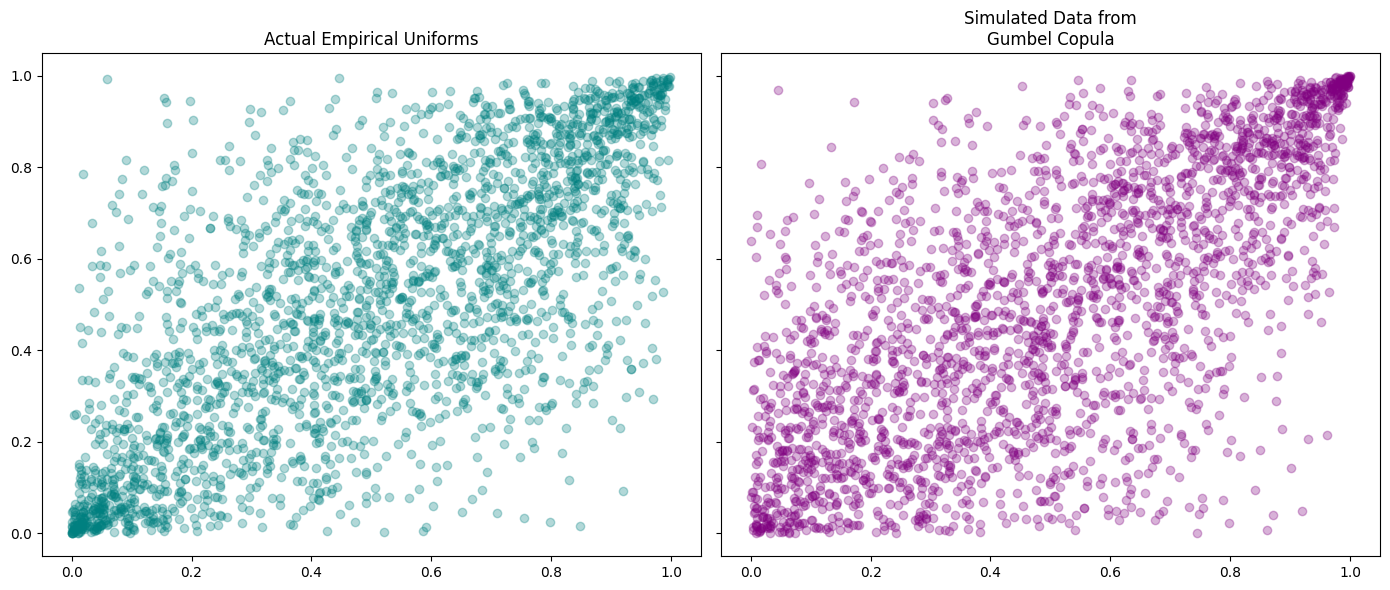

In [ ]:
# HIDE_CELL

# @title 🧮 Gumbel

from copulae import GumbelCopula
import matplotlib.pyplot as plt

# 1. Initialize and fit the Gumbel Copula
gumbel_cop = GumbelCopula(dim=2)
gumbel_cop.fit(data)

print(f"Gumbel Copula Parameter (Theta): {gumbel_cop.params:.4f}")

# 2. Visualization: Simulate data
sim_data_gumbel = gumbel_cop.random(len(data))

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Empirical Uniforms')
ax[1].scatter(sim_data_gumbel[:, 0], sim_data_gumbel[:, 1], alpha=0.3, color='purple')
ax[1].set_title('Simulated Data from\nGumbel Copula')
plt.tight_layout()
plt.show()

##### C. The Frank Copula

Summary: An Archimedean copula that is symmetric in both tails and exhibits zero tail dependence (similar to the Gaussian copula but with a different shape). It is unique because it permits the full range of dependence, from perfect countermonotonicity (perfect negative) to comonotonicity (perfect positive).The Math & Formula: Generated by $\phi(t) = -\log \left( \frac{e^{-\theta t} - 1}{e^{-\theta} - 1} \right)$.$$C(u, v; \theta) = -\frac{1}{\theta} \log \left( 1 + \frac{(e^{-\theta u} - 1)(e^{-\theta v} - 1)}{e^{-\theta} - 1} \right)$$Where $\theta \neq 0$.

Frank Copula Parameter (Theta):
6.1941
Log-Likelihood: 878.44


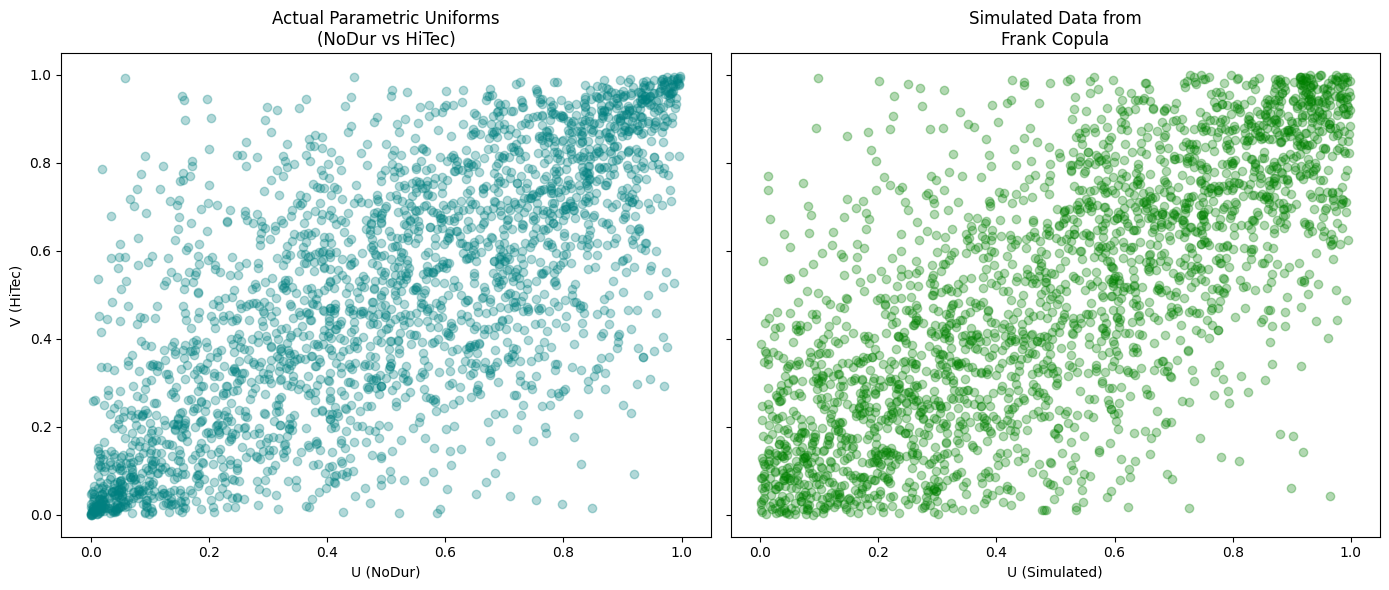

In [ ]:
# HIDE_CELL


# @title 🧮 Frank

from copulae import FrankCopula
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize and fit the Frank Copula
# Frank is an Archimedean copula symmetric in both tails with zero tail dependence
frank_cop = FrankCopula(dim=2)
frank_cop.fit(data)

print("Frank Copula Parameter (Theta):")
print(f"{frank_cop.params:.4f}")
print(f"Log-Likelihood: {frank_cop.log_lik(data):.2f}")

# 2. Visualization: Simulate data from the fitted Frank copula
sim_data_frank = frank_cop.random(len(data))

# 3. Plotting side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Actual Data
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Parametric Uniforms\n(NoDur vs HiTec)')
ax[0].set_xlabel('U (NoDur)')
ax[0].set_ylabel('V (HiTec)')

# Simulated Data (Frank)
ax[1].scatter(sim_data_frank[:, 0], sim_data_frank[:, 1], alpha=0.3, color='green')
ax[1].set_title('Simulated Data from\nFrank Copula')
ax[1].set_xlabel('U (Simulated)')

plt.tight_layout()
plt.show()

#### 3. Rotated Copulas
(Survival Copulas)To maximize flexibility, researchers often mathematically rotate these copulas by 180 degrees.The Math: To rotate a copula, you input the survival functions $(1-u)$ and $(1-v)$ instead of the standard uniform CDFs.
$$C(u,v; \theta) = \exp\left(-\left[(-\ln u)^\theta + (-\ln v)^\theta\right]^{1/\theta}\right)$$
$$C_{Rotated}(u, v; \theta) = u + v - 1 + C_{Standard}(1-u, 1-v; \theta)$$Application: A Rotated Gumbel copula takes the upper-tail dependence of a standard Gumbel and flips it to the lower tail, making it a powerful alternative to the Clayton copula for modeling market crashes.

Rotated Gumbel Copula Parameter (Theta):
2.0361

Log-Likelihood: 956.11


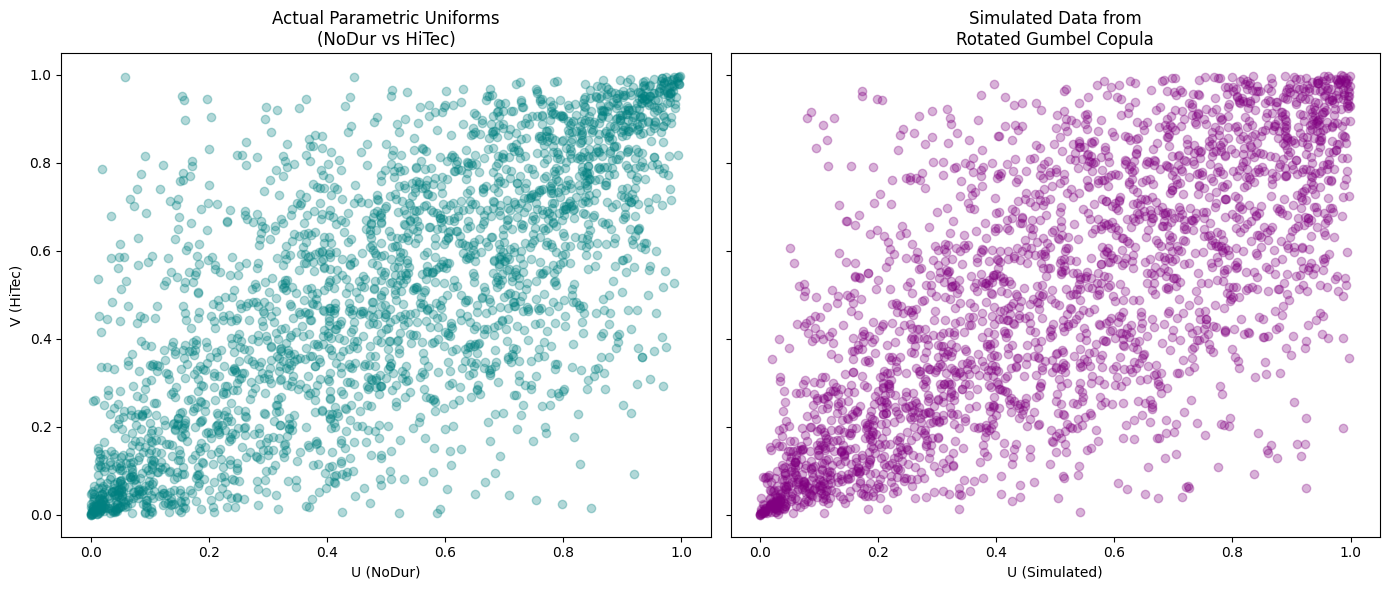

In [ ]:
# HIDE_CELL

# @title 🧮 Rotated Gumbel


from copulae import GumbelCopula
import numpy as np
import matplotlib.pyplot as plt


# 1. Rotated Gumbel (Survival Gumbel) Logic
# We fit a standard Gumbel to the survival functions (1-u, 1-v)
data_rotated = 1 - data

gumbel_rot = GumbelCopula(dim=2)
gumbel_rot.fit(data_rotated)

print("Rotated Gumbel Copula Parameter (Theta):")
print(f"{float(gumbel_rot.params):.4f}")
print(f"\nLog-Likelihood: {gumbel_rot.log_lik(data_rotated):.2f}")

# 2. Visualization: Simulate data and transform back
sim_std = gumbel_rot.random(len(data))
sim_rotated = 1 - sim_std

# 3. Plotting side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Actual Data
ax[0].scatter(data[:, 0], data[:, 1], alpha=0.3, color='teal')
ax[0].set_title('Actual Parametric Uniforms\n(NoDur vs HiTec)')
ax[0].set_xlabel('U (NoDur)')
ax[0].set_ylabel('V (HiTec)')

# Simulated Data (Rotated Gumbel)
ax[1].scatter(sim_rotated[:, 0], sim_rotated[:, 1], alpha=0.3, color='purple')
ax[1].set_title('Simulated Data from\nRotated Gumbel Copula')
ax[1].set_xlabel('U (Simulated)')

plt.tight_layout()
plt.show()

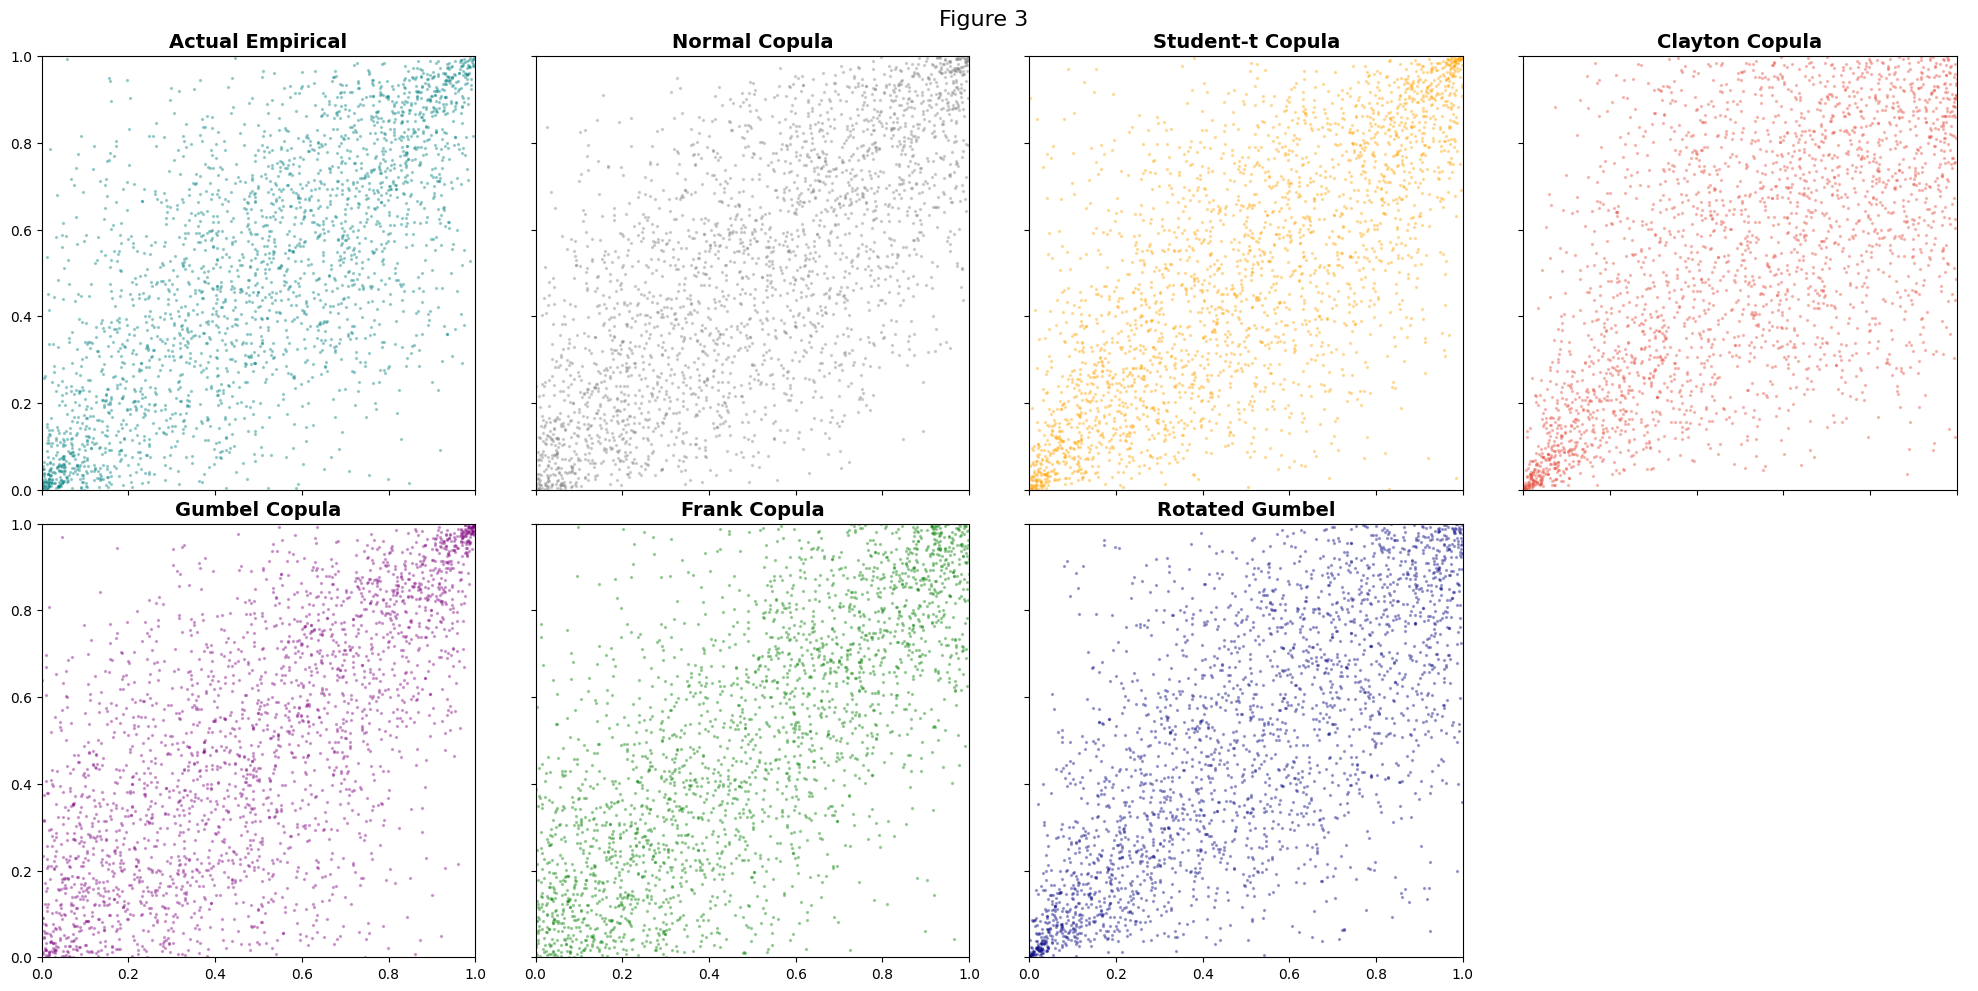

In [ ]:
# @title 📊 Plot Copulas
import matplotlib.pyplot as plt

# Define the plot grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Data and titles for the comparison
# Ensure these variables (data, sim_data_norm, etc.) are defined in your kernel
plots = [
    (data, 'Actual Empirical', 'teal'),
    (sim_data_norm, 'Normal Copula', 'gray'),
    (sim_data_t, 'Student-t Copula', 'orange'),
    (sim_data_clayton, 'Clayton Copula', '#e74c3c'),
    (sim_data_gumbel, 'Gumbel Copula', 'purple'),
    (sim_data_frank, 'Frank Copula', 'green'),
    (sim_rotated, 'Rotated Gumbel', 'navy')
]

for i, (plot_data, title, color) in enumerate(plots):
    axes[i].scatter(plot_data[:, 0], plot_data[:, 1], alpha=0.3, s=2, color=color)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_aspect('equal')

# Add figure title
plt.suptitle('Figure 3', fontsize=16)
# Remove the unused 8th subplot
axes[-1].axis('off')

plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('copula_comparison_grid.png', dpi=300, bbox_inches='tight')

plt.show()

Figure 3 shows the difference between the distributions simulated using copula models versus real data. The Gaussian (Normal) copula creates a distribution similar to a normal distribution. The t-copula makes a distribution more similar to the actual data. The Clayton copula produces a heavy left tail, while the Gumbel copula generates a heavy right tail (and the rotated Gumbel does the opposite). The Frank copula yields a distribution similar to a t-copula with low degrees of freedom.

#### Copula Comparison
We compare the goodness-of-fit using information criteria (AIC/BIC). The model with the **highest Log-Likelihood** and **lowest AIC/BIC** is statistically the best fit for the joint dependence between these two assets.

First to obtain the log-likelihood of the copula density $c(u_{1,i}, u_{2,i}; \mathbf{\theta})$ evaluated at the estimated parameters $\hat{\mathbf{\theta}}$:$$\ln L(\hat{\mathbf{\theta}}) = \sum_{i=1}^N \ln c(u_{1,i}, u_{2,i}; \hat{\mathbf{\theta}})$$Using the maximized copula log-likelihood, calculate:Akaike Information Criterion (AIC):
$$AIC = -2 \ln L(\hat{\mathbf{\theta}}) + 2k$$Bayesian Information Criterion (BIC):
$$BIC = -2 \ln L(\hat{\mathbf{\theta}}) + k \ln(N)$$

Where:$N$ = total number of observations (time series sample size).
$k$ = number of estimated parameters in the copula model:$k = 1$ for one-parameter families (Gaussian, Clayton, Gumbel, Frank).
$k = 2$ for two-parameter families (Student-$t$, which estimates correlation $\rho$ and degrees of freedom $\nu$; or BB1/BB7 copulas).

In [ ]:
# HIDE_CELL
# Install dataframe_image if not present
try:
    import dataframe_image as dfi
except ImportError:
    !pip install dataframe_image --quiet
    import dataframe_image as dfi


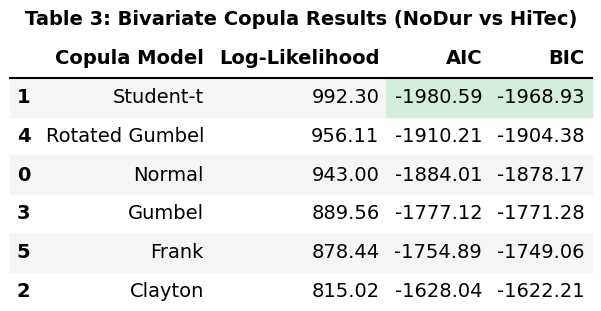

In [ ]:
import pandas as pd
import numpy as np
from copulae import NormalCopula, StudentCopula, ClaytonCopula, GumbelCopula, FrankCopula
from IPython.display import display, Image
import os


def copulas_compar(u_val, v_val):
    # 1. Prepare the data matrices
    u_val_np = u_val.values
    v_val_np = v_val.values
    data_biv = np.column_stack((u_val_np, v_val_np))
    survival_data = 1 - data_biv
    n_obs = len(data_biv)

    # 2. Fit Rotated Models
    norm_rot = NormalCopula(dim=2).fit(survival_data)
    t_rot = StudentCopula(dim=2).fit(survival_data)
    clayton_rot = ClaytonCopula(dim=2).fit(survival_data)
    frank_rot = FrankCopula(dim=2).fit(survival_data)

    # 3. List all models (Standard and Rotated)
    norm_std = NormalCopula(dim=2).fit(data_biv)
    t_std = StudentCopula(dim=2).fit(data_biv)
    clayton_std = ClaytonCopula(dim=2).fit(data_biv)
    gumbel_std = GumbelCopula(dim=2).fit(data_biv)
    frank_std = FrankCopula(dim=2).fit(data_biv)
    gumbel_rot = GumbelCopula(dim=2).fit(survival_data)

    bivariate_models = [
        {'name': 'Normal', 'model': norm_std, 'k': 1, 'rotated': False},
        {'name': 'Student-t', 'model': t_std, 'k': 2, 'rotated': False},
        {'name': 'Clayton', 'model': clayton_std, 'k': 1, 'rotated': False},
        {'name': 'Gumbel', 'model': gumbel_std, 'k': 1, 'rotated': False},
        {'name': 'Rotated Gumbel', 'model': gumbel_rot, 'k': 1, 'rotated': True},
        {'name': 'Frank', 'model': frank_std, 'k': 1, 'rotated': False},
    ]

    comparison_results = []
    for item in bivariate_models:
        m = item['model']
        k = item['k']
        eval_data = survival_data if item['rotated'] else data_biv
        ll = m.log_lik(eval_data)
        aic = -2 * ll + 2 * k
        bic = -2 * ll + np.log(n_obs) * k
        comparison_results.append({'Copula Model': item['name'], 'Log-Likelihood': ll, 'AIC': aic, 'BIC': bic})

    return pd.DataFrame(comparison_results).sort_values(by='AIC')

# Calculate Results
biv_comp_df = copulas_compar(u_val=df_2007_2017['uparam_NoDur'], v_val=df_2007_2017['uparam_HiTec'])

# Create styled table
styled_table = biv_comp_df.style.set_caption("Table 3: Bivariate Copula Results (NoDur vs HiTec)") \
    .highlight_min(subset=['AIC', 'BIC'], color='#d4edda') \
    .format({'Log-Likelihood': '{:.2f}', 'AIC': '{:.2f}', 'BIC': '{:.2f}'}) \
    .set_properties(**{'text-align': 'left', 'font-family': 'sans-serif', 'border': '1px solid #dee2e6'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#212529'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('color', '#495057'), ('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])

# Export to Image using 'matplotlib' instead of 'chrome' to avoid OSError
output_image = "copula_comparison.png"
dfi.export(styled_table, output_image, table_conversion="matplotlib")

# Display the PNG
display(Image(filename=output_image))

Table 3 shows that the Student-t copula performs better.

The most important point in this table is that the Rotated Gumbel copula works better than the regular Gumbel. This reveals that these two assets have lower-tail dependence (i.e., they crash together).

# Methology and Data

## Copula setup

To model the entire portfolio of 10 assets, we fit a multivariate copula.

Because the joint distribution of a portfolio modeled by an asymmetric Archimedean copula lacks a closed-form analytical solution for aggregate tail risk, we follow the standard computational framework outlined by Patton (2012). We utilize Monte Carlo simulation(N = 10K) to draw from the fitted copula, reconstruct the joint return distribution via the inverse Probability Integral Transform, and use spearman correaltion to find numerically evaluate the correlation matrix.

The correlation matrix will be used to optimize the portfolio volatility.

In [ ]:
 # HIDE_CELL
from copulae import NormalCopula
import pandas as pd
# 1. Collect empirical uniform data for all assets (already prepared in previous steps)
all_u_cols = [f'uparam_{asset}' for asset in asset_list]
multi_data_norm = df_2007_2017[all_u_cols].values

num_assets = len(asset_list)

# 2. Initialize and fit the Multivariate Normal (Gaussian) Copula
multi_norm_cop = NormalCopula(dim=num_assets)
multi_norm_cop.fit(multi_data_norm)

print(f"Multivariate Normal Copula fitted across {num_assets} assets.")


# ==============================================================================
# 3. SIMULATE THE DATA (Required for Portfolio Optimization)
# ==============================================================================
n_simulations = 10000
print(f"\nSimulating {n_simulations} market scenarios...")

# Draw joint uniform probability scenarios directly from the fitted Gaussian object
simulated_uniforms_norm = multi_norm_cop.random(n_simulations)

# Convert the simulated uniform data into a DataFrame mapped to your assets
# THIS 'simulated_norm_df' is the dataframe you will map back to returns for your optimizer
simulated_norm_df = pd.DataFrame(simulated_uniforms_norm, columns=asset_list)

# 4. Calculate the Correlation Matrix from the SIMULATED data (Rank Correlation)
corr_matrix_norm_df = simulated_norm_df.corr(method='spearman')


Multivariate Normal Copula fitted across 10 assets.

Simulating 10000 market scenarios...


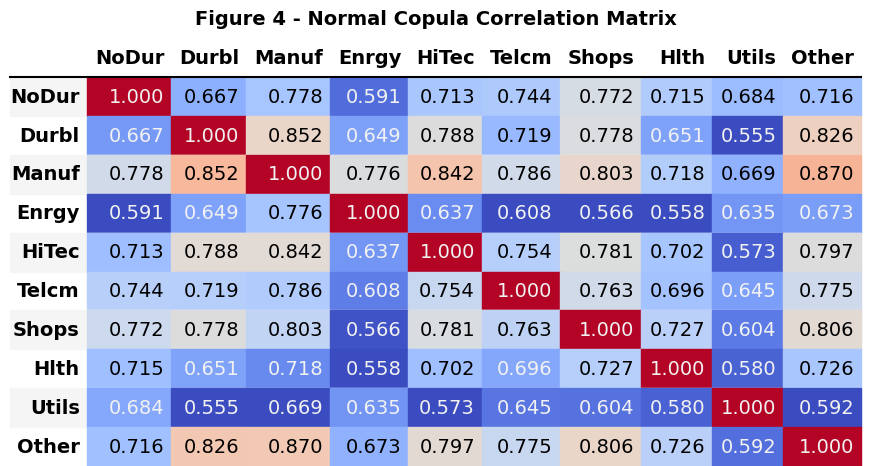

In [ ]:
import dataframe_image as dfi
from IPython.display import Image, display

# Create the styled dataframe with the requested title
styled_corr = corr_matrix_norm_df.style.set_caption("Figure 4 - Normal Copula Correlation Matrix") \
    .background_gradient(cmap='coolwarm') \
    .format("{:.3f}")

# Export to PNG using matplotlib engine to avoid Chrome dependency
output_png = "normal_copula_corr.png"
dfi.export(styled_corr, output_png, table_conversion="matplotlib")

display(Image(filename=output_png))

In [ ]:
 # HIDE_CELL
from copulae import StudentCopula
import pandas as pd

# 1. Collect empirical uniform data for all assets
all_u_cols = [f'uparam_{asset}' for asset in asset_list]
multi_data = df_2007_2017[all_u_cols].values

# 2. Initialize and fit the Multivariate Student-t Copula
multi_t_cop = StudentCopula(dim=len(asset_list))
multi_t_cop.fit(multi_data)

print(f"Multivariate Student-t Copula fitted across {len(asset_list)} assets.")
print(f"Estimated Degrees of Freedom (Nu): {multi_t_cop.params.df:.4f}")



Multivariate Student-t Copula fitted across 10 assets.
Estimated Degrees of Freedom (Nu): 8.4881


In [ ]:
# 3. Simulate 10,000 joint scenarios from the fitted copula
n_simulations = 10000
simulated_uniforms = multi_t_cop.random(n_simulations)

# Convert the simulated uniform data into a DataFrame
simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# 4. Calculate the Copula-implied Correlation Matrix from the SIMULATED data
# We use 'spearman' to isolate the rank dependence
corr_matrix_t_sim_df = simulated_df.corr(method='spearman')

# Create the styled dataframe for Student-t Copula
styled_t_corr = corr_matrix_t_sim_df.style.background_gradient(cmap='coolwarm').format("{:.3f}")


### Clayton Copula Vs Vine:

The Clyton Capula estimate one prameters, so the spearman correalion matrix is very close to gather(figure 5), so we have to use vine copula.

In [ ]:
# HIDE_CELL
import numpy as np
import pandas as pd
from copulae import ClaytonCopula

# --- Inputs from your previous cells ---
all_u_cols = [f'uparam_{asset}' for asset in asset_list]
multi_data_clayton = df_2007_2017[all_u_cols].values

# 1. Determine dimensions
num_assets = len(asset_list)

# 2. Instantiate the Multivariate Clayton Copula
# dim=10 tells the library to expect a 10-column input array
clayton_multi = ClaytonCopula(dim=num_assets)

print(f"Fitting the {num_assets}-dimensional Clayton Copula...")
# Fit the copula to your empirical uniform data (Probability Integral Transforms)
clayton_multi.fit(multi_data_clayton)

# Extract the single fitted dependence parameter
fitted_theta = clayton_multi.params
print(f"Fitted Clayton Parameter (\u003Ctheta\u003E): {fitted_theta:.4f}")

# Calculate theoretical Kendall's Tau for context
theoretical_tau = fitted_theta / (fitted_theta + 2)
print(f"Theoretical Copula-Implied Kendall's Tau: {theoretical_tau:.4f}\n")

# 3. Simulate from the fitted copula to generate the correlation matrix
# We simulate 10,000 joint scenarios to ensure statistical stability
n_simulations = 10000
simulated_uniforms = clayton_multi.random(n_simulations)

# Convert the simulated uniform data into a DataFrame, mapping back your asset names
simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# 4. Calculate the Copula-implied Correlation Matrix
# We use 'spearman' (Rank Correlation) because copulas model rank dependence,
# strictly isolating the copula's effect without being skewed by marginal outliers.
corr_matrix_clayton_df = simulated_df.corr(method='spearman')

# Create the styled dataframe for Clayton Copula
styled_clayton_corr = corr_matrix_clayton_df.style.background_gradient(cmap='coolwarm').format("{:.3f}")


Fitting the 10-dimensional Clayton Copula...
Fitted Clayton Parameter (<theta>): 1.1559
Theoretical Copula-Implied Kendall's Tau: 0.3663



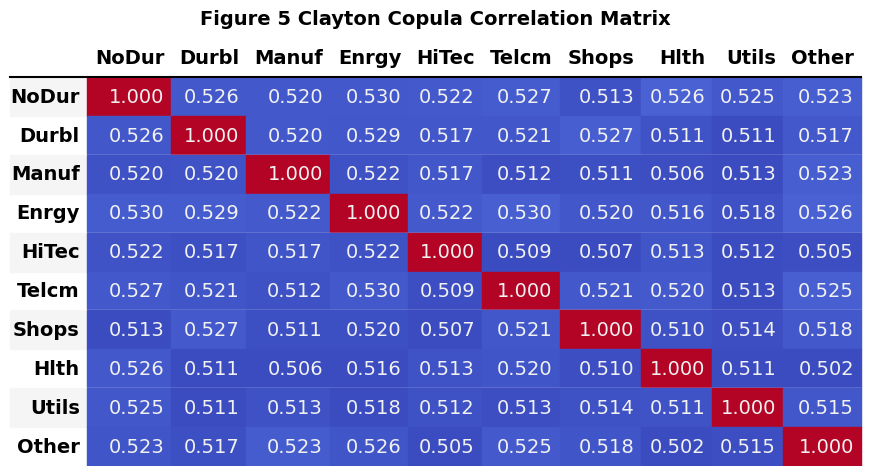

In [ ]:
# @title 📊 clayton Copula Correlation Heatmap {display-mode: "form"}

import dataframe_image as dfi
from IPython.display import Image, display

# 5. Add caption and export to PNG
styled_clayton_corr_with_title = corr_matrix_clayton_df.style.set_caption("Figure 5 Clayton Copula Correlation Matrix") \
    .background_gradient(cmap='coolwarm') \
    .format("{:.3f}")

# Export to PNG using matplotlib engine
output_png_clayton = "clayton_copula_corr.png"
dfi.export(styled_clayton_corr_with_title, output_png_clayton, table_conversion="matplotlib")

display(Image(filename=output_png_clayton))


#### Vine Copula:

A vine copula uses Pair-Copula Construction (PCC) to break down a complex, multi-dimensional joint density into a product of simple, two-dimensional copulas.The general formula for the joint density function $f(x_1, \dots, x_n)$ is:
$$f(x_1, \dots, x_n) = \prod_{k=1}^n f_k(x_k) \prod_{j=1}^{n-1} \prod_{i=1}^{n-j} c_{i, i+j \vert{} S}$$

* $f_k(x_k)$: The marginal probability density function of each individual variable.
* $c_{i, i+j \vert{} S}$: The bivariate copula density connecting two variables, given a conditioning set of other variables $S$.

In [ ]:
# HIDE_CELL
try:
    import pyvinecopulib as pv
except ImportError:
    print("pyvinecopulib not found. Installing now...")
    !pip install pyvinecopulib
    import pyvinecopulib as pv

try:
    from pypfopt import EfficientFrontier
except ImportError:
    print("PyPortfolioOpt not found. Installing now...")
    # Note: The package name is PyPortfolioOpt, but the module is pypfopt
    !pip install PyPortfolioOpt
    from pypfopt import EfficientFrontier

pyvinecopulib not found. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.1 MB/s eta 0:00:00
PyPortfolioOpt not found. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 12.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pyvinecopulib as pv
from pypfopt import EfficientFrontier

# --- Inputs from your previous cells ---
# Assuming 'multi_data_vine' is already defined in your environment
# and contains your pseudo-observations (uniforms).
multi_data_vine = multi_data_clayton
# 1. Determine the dimension (number of assets/columns)
num_assets = multi_data_vine.shape[1]

print("Fitting the Vine Copula (this may take a moment)...")
# 2. Instantiate an empty Vinecop object with the specific dimension 'd'
vine_copula = pv.Vinecop(d=num_assets)

# 3. Fit the structure, families, and parameters to your data
vine_copula.select(data=multi_data_vine)

# 4. Run Monte Carlo Simulation
n_simulations = 10000
print(f"Running Monte Carlo simulation with {n_simulations} paths...")
simulated_data = vine_copula.simulate(n=n_simulations)

# 5. Store the simulated data in a Pandas DataFrame
# (Replace all_u_cols with your actual column name list if needed)
all_u_cols = [f'uparam_{i}' for i in range(num_assets)]
df_simulated = pd.DataFrame(simulated_data, columns=all_u_cols)


Fitting the Vine Copula (this may take a moment)...
Running Monte Carlo simulation with 10000 paths...


In [ ]:

# 6. Calculate the Spearman correlation of the simulated data
vine_corr_matrix = df_simulated.corr(method='spearman')


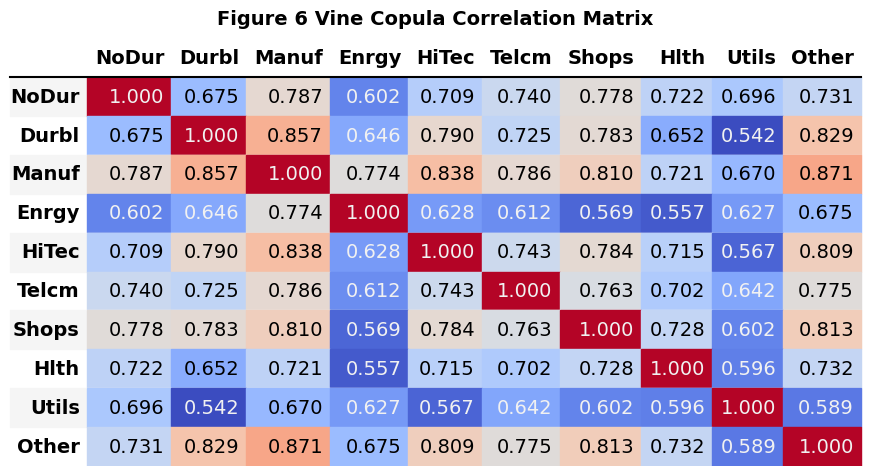

In [ ]:
# @title 📊 Vine Copula Correlation Heatmap {display-mode: "form"}

import dataframe_image as dfi
from IPython.display import Image, display
import pandas as pd

# Ensure we are using the actual asset names for the labels
# Mapping from generic 'uparam_i' to 'asset_list' names
vine_corr_matrix.index = asset_list
vine_corr_matrix.columns = asset_list

# 1. Create a styled dataframe with a color gradient and the requested title
styled_vine_corr = vine_corr_matrix.style.set_caption("Figure 6 Vine Copula Correlation Matrix") \
    .background_gradient(cmap='coolwarm', axis=None) \
    .format("{:.3f}")

# 2. Export the styled table to a PNG file using the matplotlib engine
output_png_vine = "vine_copula_corr.png"
dfi.export(styled_vine_corr, output_png_vine, table_conversion="matplotlib")

display(Image(filename=output_png_vine))

In [ ]:
 # HIDE_CELL

import numpy as np
import pandas as pd
from copulae import GumbelCopula

# --- Inputs from your previous cells ---
# all_u_cols = [f'uparam_{asset}' for asset in asset_list]
# multi_data_uniforms = df_2007_2017[all_u_cols].values  # Previously multi_data_clayton

# 1. Determine dimensions
num_assets = len(asset_list)

# 2. Instantiate the Multivariate Gumbel Copula
# dim=10 tells the library to expect a 10-column input array
gumbel_multi = GumbelCopula(dim=num_assets)

print(f"Fitting the {num_assets}-dimensional Gumbel Copula...")
# Fit the copula to your empirical uniform data (Probability Integral Transforms)
# Note: You can pass your existing 'multi_data_clayton' array here, as it just contains uniform margins
gumbel_multi.fit(multi_data_clayton)

# Extract the single fitted dependence parameter
fitted_theta = gumbel_multi.params
print(f"Fitted Gumbel Parameter (\u003Ctheta\u003E): {fitted_theta:.4f}")

# Calculate theoretical Kendall's Tau for context
theoretical_tau = 1 - (1 / fitted_theta)
print(f"Theoretical Copula-Implied Kendall's Tau: {theoretical_tau:.4f}\n")

# 3. Simulate from the fitted copula to generate the correlation matrix
# We simulate 10,000 joint scenarios to ensure statistical stability
n_simulations = 10000
simulated_uniforms = gumbel_multi.random(n_simulations)

# Convert the simulated uniform data into a DataFrame, mapping back your asset names
simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# 4. Calculate the Copula-implied Correlation Matrix
# We use 'spearman' (Rank Correlation) to isolate the copula's structural dependence
corr_matrix_gumbel_df = simulated_df.corr(method='spearman')

# Create the styled dataframe for Gumbel Copula
styled_gumbel_corr = corr_matrix_gumbel_df.style.background_gradient(cmap='coolwarm').format("{:.3f}")



Fitting the 10-dimensional Gumbel Copula...
Fitted Gumbel Parameter (<theta>): 1.7822
Theoretical Copula-Implied Kendall's Tau: 0.4389



In [ ]:
 # HIDE_CELL
import numpy as np
import pandas as pd
from copulae import GumbelCopula

# --- Inputs from your previous cells ---
# all_u_cols = [f'uparam_{asset}' for asset in asset_list]
# multi_data_uniforms = df_2007_2017[all_u_cols].values # Your original uniform margins

num_assets = len(asset_list)

# ==============================================================================
# 1. ROTATE THE DATA (SURVIVAL TRANSFORMATION)
# ==============================================================================
# Subtract the uniform margins from 1.0 to flip the dependence structure 180 degrees
multi_data_rotated = 1.0 - multi_data_clayton

# ==============================================================================
# 2. FIT THE COPULA TO ROTATED DATA
# ==============================================================================
print(f"Fitting the {num_assets}-dimensional Rotated (Survival) Gumbel Copula...")
gumbel_rot_multi = GumbelCopula(dim=num_assets)

# Fit using the flipped data
gumbel_rot_multi.fit(multi_data_rotated)

fitted_theta = gumbel_rot_multi.params
print(f"Fitted Rotated Gumbel Parameter (\u003Ctheta\u003E): {fitted_theta:.4f}")

# ==============================================================================
# 3. SIMULATE AND RE-ROTATE
# ==============================================================================
n_simulations = 10000

# Simulate from the fitted rotated copula
simulated_rotated_uniforms = gumbel_rot_multi.random(n_simulations)

# Reverse the rotation to bring the data back into standard asset space
simulated_uniforms = 1.0 - simulated_rotated_uniforms

simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# ==============================================================================
# 4. CALCULATE CORRELATION MATRIX
# ==============================================================================
# Calculate Spearman Rank Correlation
corr_matrix_gumbel_rot_df = simulated_df.corr(method='spearman')
# Create the styled dataframe
styled_gumbel_rot_corr = corr_matrix_gumbel_rot_df.style.background_gradient(cmap='coolwarm').format("{:.3f}")



Fitting the 10-dimensional Rotated (Survival) Gumbel Copula...
Fitted Rotated Gumbel Parameter (<theta>): 1.8017


In [ ]:
 # HIDE_CELL

import numpy as np
import pandas as pd
from copulae import StudentCopula

# --- Inputs from your previous cells ---
# all_u_cols = [f'uparam_{asset}' for asset in asset_list]
# multi_data_uniforms = df_2007_2017[all_u_cols].values # Your original uniform margins

num_assets = len(asset_list)

# ==============================================================================
# 1. ROTATE THE DATA (SURVIVAL TRANSFORMATION)
# ==============================================================================
# Subtract the uniform margins from 1.0 to flip the dependence structure 180 degrees
multi_data_rotated = 1.0 - multi_data_clayton  # Assuming this holds your uniform margins

# ==============================================================================
# 2. FIT THE COPULA TO ROTATED DATA
# ==============================================================================
print(f"Fitting the {num_assets}-dimensional Rotated (Survival) Student-t Copula...")
t_rot_multi = StudentCopula(dim=num_assets)

# Fit using the flipped data
t_rot_multi.fit(multi_data_rotated)

# The Student-t copula has two sets of parameters:
# 1. Degrees of Freedom (nu)
# 2. The implied correlation matrix (dispersion matrix)
df_nu = t_rot_multi.params.df
print(f"Fitted Degrees of Freedom (\u03BD): {df_nu:.4f}")
print("Note: Lower degrees of freedom means fatter, more extreme tails.\n")

# ==============================================================================
# 3. SIMULATE AND RE-ROTATE
# ==============================================================================
n_simulations = 10000

# Simulate from the fitted rotated copula
simulated_rotated_uniforms = t_rot_multi.random(n_simulations)

# Reverse the rotation to bring the data back into standard asset space
simulated_uniforms = 1.0 - simulated_rotated_uniforms

simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# ==============================================================================
# 4. CALCULATE CORRELATION MATRIX
# ==============================================================================
# Calculate Spearman Rank Correlation
corr_matrix_t_rot_df = simulated_df.corr(method='spearman')



Fitting the 10-dimensional Rotated (Survival) Student-t Copula...
Fitted Degrees of Freedom (ν): 8.4880
Note: Lower degrees of freedom means fatter, more extreme tails.



In [ ]:
 # HIDE_CELL
import numpy as np
import pandas as pd
from copulae import ClaytonCopula

# --- Inputs from your previous cells ---
# all_u_cols = [f'uparam_{asset}' for asset in asset_list]
# multi_data_uniforms = df_2007_2017[all_u_cols].values # Your original uniform margins

num_assets = len(asset_list)

# ==============================================================================
# 1. ROTATE THE DATA (SURVIVAL TRANSFORMATION)
# ==============================================================================
# Subtract the uniform margins from 1.0 to flip the dependence structure 180 degrees
multi_data_rotated = 1.0 - multi_data_clayton

# ==============================================================================
# 2. FIT THE COPULA TO ROTATED DATA
# ==============================================================================
print(f"Fitting the {num_assets}-dimensional Rotated (Survival) Clayton Copula...")
clayton_rot_multi = ClaytonCopula(dim=num_assets)

# Fit using the flipped data
clayton_rot_multi.fit(multi_data_rotated)

fitted_theta = clayton_rot_multi.params
print(f"Fitted Rotated Clayton Parameter (\u003Ctheta\u003E): {fitted_theta:.4f}")

# ==============================================================================
# 3. SIMULATE AND RE-ROTATE
# ==============================================================================
n_simulations = 10000

# Simulate from the fitted rotated copula
simulated_rotated_uniforms = clayton_rot_multi.random(n_simulations)

# Reverse the rotation to bring the data back into standard asset space
simulated_uniforms = 1.0 - simulated_rotated_uniforms

simulated_df = pd.DataFrame(simulated_uniforms, columns=asset_list)

# ==============================================================================
# 4. CALCULATE CORRELATION MATRIX
# ==============================================================================
# Calculate Spearman Rank Correlation to isolate the copula's structural dependence
corr_matrix_clayton_rot_df = simulated_df.corr(method='spearman')



Fitting the 10-dimensional Rotated (Survival) Clayton Copula...
Fitted Rotated Clayton Parameter (<theta>): 0.9335


In [ ]:

# HIDE_CELL
def calculate_garch_correlation_matrix(industry_returns, asset_list):
    """
    Calculates the Pearson correlation matrix of standardized residuals
    using a fixed EGARCH(1,1) model for all assets.
    """
    standardized_residuals_dict = {}

    for asset in asset_list:
        # Prepare the returns data
        returns = industry_returns[asset].dropna()

        # Initialize and fit EGARCH(1,1) for all assets
        # Using Student's t distribution to account for heavy tails in financial data
        model = arch_model(
            returns,
            mean='Constant',
            vol='EGARCH',
            p=1,
            o=1,
            q=1,
            dist='studentst'
        )

        res = model.fit(disp='off', show_warning=False)

        # Calculate standardized residuals: (epsilon_t / sigma_t)
        standardized_residuals_dict[asset] = res.resid / res.conditional_volatility

    df_std_resid = pd.DataFrame(standardized_residuals_dict)
    return df_std_resid.corr(method='pearson')

In [ ]:
# HIDE_CELL
Garch_corr_matrix = calculate_garch_correlation_matrix(
    industry_returns=df_2007_2017,
    asset_list=asset_list)


In [ ]:
# HIDE_CELL
# Map of model names to their respective correlation matrices
rank_corr_matrix = {
    'Copula-Normal': corr_matrix_norm_df,
    'Copula-t': corr_matrix_t_sim_df,
    'Copula-Clayton': corr_matrix_clayton_df,
    'Copula-Vine': vine_corr_matrix,
    'Copula-Gumbel': corr_matrix_gumbel_df,
    'Copula-Rotated-t': corr_matrix_t_rot_df,
    'Copula-Rotated-Gumbel': corr_matrix_gumbel_rot_df,
    'Copula-Rotated-Clayton': corr_matrix_clayton_rot_df,
    'GARCH-CCC': Garch_corr_matrix
}


## Global Minimum Variance(GMV)
with Copula/CCC-GARCH

 to compare the advanced Copula models with the baseline Constant Conditional Correlation (CCC) model, we use the GMV framework to construct an optimized, risk-minimizing portfolio.

 The workflow follows three steps:

 1. Fit the Marginal Models (Extract Volatility):

    Apply univariate GARCH models to each individual asset to filter the returns and forecast the 1-step-ahead conditional volatility (standard deviation.

 2. Construct the Implied Covariance Matrix ($\Sigma$):

    Reconstruct the full portfolio covariance matrix using the decomposition formula:
    
    
    
    $\Sigma = D \times R \times D$


    * $D$: The Diagonal Matrix containing the 1-step-ahead univariate GARCH conditional standard deviations (volatilities) on the diagonal, and zeros elsewhere(Figure 6).
    * $R$: The Correlation Matrix:

      * For the Baseline: This is the static Pearson correlation matrix of the GARCH residuals (CCC).
      * For the Copulas: This is the Copula-implied rank correlation matrix, derived from simulating thousands of joint market scenarios.
    
 3. GMV Optimization:
    
    Apply Markowitz matrix algebra
    (minimizing $w^T \Sigma w$) to the reconstructed covariance matrix to find the exact asset weight vector ($w$) that strictly minimizes the total expected portfolio variance, subject to the constraint that the weights sum to 100%(figure 7).

    * Because prohibiting short trades destroys part of the advantage of copula models, short trades are considered in this research.

In [ ]:

# HIDE_CELL
try:
    import pypfopt
except ImportError:
    # Step 1: Pre-install the core solvers directl
    !pip install cvxpy ecos scs qdldl --quiet
    # Step 2: Install PyPortfolioOpt without relying on broken dependency builds
    !pip install PyPortfolioOpt --quiet
    print("PyPortfolioOpt installed successfully!")

In [ ]:
# @title 🧮 GMV long {display-mode: "form"}

import numpy as np
import pandas as pd
from arch import arch_model
from pypfopt import EfficientFrontier

def GMV_optimization_long(returns_df, asset_list, correlation_matrix):
    """
    Optimizes a GMV portfolio using a fixed EGARCH(1,1) model for all assets
    and a provided Copula correlation matrix. Long-only constraint.

    Inputs:
    - returns_df: pandas DataFrame containing the historical returns.
    - asset_list: list of asset names.
    - correlation_matrix: 10x10 array or DataFrame.

    Returns:
    - optimal_weights: pandas Series of the optimized GMV asset weights.
    - D: The diagonal matrix of forecasted volatilities.
    """

    # ---------------------------------------------------------
    # STEP 1: Fit Marginal Models and Extract Volatility (D)
    # ---------------------------------------------------------
    forecasted_vols = []

    for asset in asset_list:
        returns = returns_df[asset].dropna()

        # Standardize to EGARCH(1,1) with Student's t for all assets
        model = arch_model(
            returns,
            mean='Constant',
            vol='EGARCH',
            p=1,
            o=1,
            q=1,
            dist='studentst'
        )

        res = model.fit(disp='off', show_warning=False)

        # Forecast the 1-step-ahead conditional variance
        forecast = res.forecast(horizon=1)
        next_day_variance = forecast.variance.iloc[-1, 0]

        # Convert variance to volatility and store
        forecasted_vols.append(np.sqrt(next_day_variance))

    # ---------------------------------------------------------
    # STEP 2: Construct the Covariance Matrix (Sigma = D * R * D)
    # ---------------------------------------------------------
    D = np.diag(forecasted_vols)

    if isinstance(correlation_matrix, pd.DataFrame):
        R = correlation_matrix.values
    else:
        R = correlation_matrix

    Sigma = D @ R @ D
    cov_df = pd.DataFrame(Sigma, index=asset_list, columns=asset_list)

    # ---------------------------------------------------------
    # STEP 3: GMV Optimization (LONG ONLY)
    # ---------------------------------------------------------
    dummy_returns = pd.Series(0, index=asset_list)

    # Initialize the optimizer with long-only constraint (weight_bounds=(0, 1))
    ef = EfficientFrontier(dummy_returns, cov_df, weight_bounds=(0, 1))

    # Solve for Global Minimum Variance
    raw_weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()

    return pd.Series(cleaned_weights), D

In [ ]:
# @title 🧮 GMV short {display-mode: "form"}

import numpy as np
import pandas as pd
from arch import arch_model
from pypfopt import EfficientFrontier

def GMV_optimization_short(returns_df, asset_list, correlation_matrix):
    """
    Optimizes a GMV portfolio using a fixed EGARCH(1,1) model for all assets
    and a provided Copula correlation matrix. Allows for short trading.

    Inputs:
    - returns_df: pandas DataFrame containing the historical returns.
    - asset_list: list of asset names.
    - correlation_matrix: 10x10 array or DataFrame.

    Returns:
    - optimal_weights: pandas Series of the optimized GMV asset weights.
    - D: The diagonal matrix of forecasted volatilities.
    """

    # ---------------------------------------------------------
    # STEP 1: Fit Marginal Models and Extract Volatility (D)
    # ---------------------------------------------------------
    forecasted_vols = []

    for asset in asset_list:
        returns = returns_df[asset].dropna()

        # Initialize and fit EGARCH(1,1) for all assets
        # Using Student's t distribution to account for heavy tails
        model = arch_model(
            returns,
            mean='Constant',
            vol='EGARCH',
            p=1,
            o=1,
            q=1,
            dist='studentst'
        )

        # Fit the model
        res = model.fit(disp='off', show_warning=False)

        # Forecast the 1-step-ahead conditional variance
        forecast = res.forecast(horizon=1)
        next_day_variance = forecast.variance.iloc[-1, 0]

        # Convert variance to volatility (standard deviation) and store
        forecasted_vols.append(np.sqrt(next_day_variance))

    # ---------------------------------------------------------
    # STEP 2: Construct the Covariance Matrix (Sigma = D * R * D)
    # ---------------------------------------------------------
    D = np.diag(forecasted_vols)

    if isinstance(correlation_matrix, pd.DataFrame):
        R = correlation_matrix.values
    else:
        R = correlation_matrix

    Sigma = D @ R @ D
    cov_df = pd.DataFrame(Sigma, index=asset_list, columns=asset_list)

    # ---------------------------------------------------------
    # STEP 3: GMV Optimization (WITH SHORT SELLING)
    # ---------------------------------------------------------
    dummy_returns = pd.Series(0, index=asset_list)

    # Initialize the optimizer with SHORT TRADING enabled [-1.0, 1.0]
    ef = EfficientFrontier(dummy_returns, cov_df, weight_bounds=(-1.0, 1.0))

    # Solve for Global Minimum Variance
    raw_weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()

    return pd.Series(cleaned_weights), D

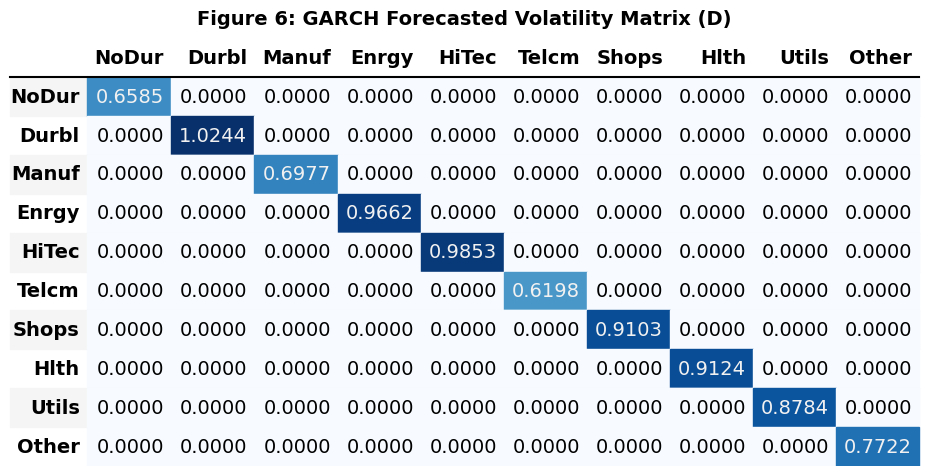

In [ ]:
# @title 📊 GARCH Conditional Volatility (Matrix D) {display-mode: "form"}

try:
    import dataframe_image as dfi
except ImportError:
    !pip install dataframe_image --quiet
    import dataframe_image as dfi

import pandas as pd
import numpy as np
from IPython.display import Image, display


weights_short , D = GMV_optimization_short(
        returns_df=df_2007_2017,
        asset_list=asset_list,
        correlation_matrix=Garch_corr_matrix
    )

# 1. Convert the diagonal matrix D into a labeled DataFrame
# We use the asset_list defined earlier for rows and columns
df_vols = pd.DataFrame(D, index=asset_list, columns=asset_list)

# 2. Extract only the diagonal (since it's a diagonal matrix) for a cleaner view
# Or style the full matrix if preferred. Here we style the full matrix as requested.
styled_d = df_vols.style.set_caption("Figure 6: GARCH Forecasted Volatility Matrix (D)") \
    .background_gradient(cmap='Blues', axis=None) \
    .format("{:.4f}") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold')]}
    ])

# 3. Export to PNG using matplotlib engine
output_png_d = "volatility_matrix_d.png"
dfi.export(styled_d, output_png_d, table_conversion="matplotlib")

# 4. Display the resulting image
display(Image(filename=output_png_d))

In [ ]:
# HIDE_CELL
gmv_weights_results = {}

# Iterate through the dictionary of correlation matrices
for model_name, corr_matrix in rank_corr_matrix.items():
    print(f"Optimizing GMV for: {model_name}")

    # Calculate weights
    weights = GMV_optimization_short(
        returns_df=df_2007_2017,
        asset_list=asset_list,
        correlation_matrix=corr_matrix
    )

    gmv_weights_results[model_name] = weights

# Combine results into a single DataFrame for easy comparison
gmv_comparison_Short_df = pd.DataFrame(gmv_weights_results)


Optimizing GMV for: Copula-Normal
Optimizing GMV for: Copula-t
Optimizing GMV for: Copula-Clayton
Optimizing GMV for: Copula-Vine
Optimizing GMV for: Copula-Gumbel
Optimizing GMV for: Copula-Rotated-t
Optimizing GMV for: Copula-Rotated-Gumbel
Optimizing GMV for: Copula-Rotated-Clayton
Optimizing GMV for: GARCH-CCC


Figure 7 displays the a sample of optimized asset weights for each model.

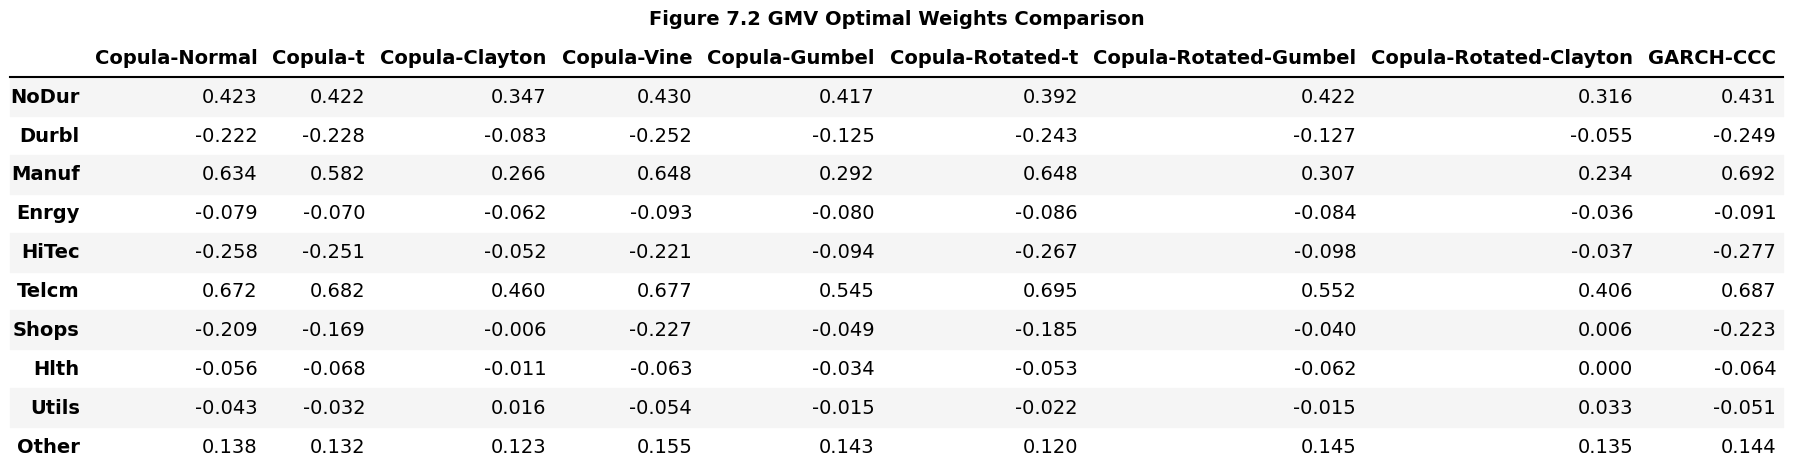

In [ ]:
# @title 📊 Weights
import dataframe_image as dfi
from IPython.display import Image, display
import pandas as pd

# --- FIX: Extract only the weights (scalars) from the comparison results ---
# The gmv_comparison_df currently contains tuples/series.
# We need a clean DataFrame of just the weight values.

clean_weights_dict = {}
for model_name in gmv_comparison_Short_df.columns:
    # Assuming the first element of the stored result is the Series of weights
    data_item = gmv_comparison_Short_df[model_name].iloc[0]
    if isinstance(data_item, pd.Series):
        clean_weights_dict[model_name] = data_item
    else:
        # Fallback if structure varies
        clean_weights_dict[model_name] = gmv_comparison_Short_df[model_name]

df_weights_final = pd.DataFrame(clean_weights_dict)

# --- Display Results and Export to PNG ---

# Style the clean dataframe: adding the figure title and keeping 3 decimal places
styled_gmv = df_weights_final.style.set_caption("Figure 7.2 GMV Optimal Weights Comparison") \
    .format("{:.3f}")

# Export to PNG using the matplotlib engine
output_png_gmv = "gmv_weights_comparison.png"
dfi.export(styled_gmv, output_png_gmv, table_conversion="matplotlib")

# Display the resulting image in the notebook
display(Image(filename=output_png_gmv))

## Comparing the portfolios

In this part i use Diebold Mariano test to comparing the models with bench mark.


### Diebold-Mariano test

The Diebold-Mariano (DM) test is a statistical hypothesis test used to compare the forecasting accuracy of two competing predictive models.

The DM test, simply looking at which model has a lower average error (or "Loss"). A slight difference might just be due to random statistical noise. The DM test evaluates whether the difference in their forecasting errors is statistically significant or if it just happened by chance.

How to Estimate the DM Test:

* asymmetric tick-loss function for risk (VaR).Let $L_{A,t}$ be the loss of Model A  at time $t$.Let $L_{B,t}$ be the loss of Model B at time $t$.

* Calculate the Loss Differential:

$$d_t = L_{A,t} - L_{B,t}$$

* Calculate the Sample Mean of the Differential:

$$\bar{d} = \frac{1}{T} \sum_{t=1}^{T} d_t$$

* Compute the DM Statistic:

$$DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d}) / T}}$$

The DM statistic follows a standard normal distribution ($\mathcal{N}(0, 1)$) in large samples. To conclude, you evaluate the DM statistic against the critical values for a 95% confidence level($\pm 1.96$).
*
The Null Hypothesis ($H_0$): Both models have equal forecasting accuracy.


## Data

For this research, I utilized the 10-industry portfolio value-weighted return data from the Kenneth R. French Data Library.

According to the library's methodology, stocks listed on the NYSE, AMEX, and NASDAQ are assigned to an industry portfolio at the end of June of year t, using their four-digit SIC codes at that time.

The models used the data between 2000/01 until 2023/12.

## Out of Sample Evaluation:
**Dual Rolling Window Methodology:**

To evaluate the true out of sample forecasting performance of the proposed Copula-GARCH framework, we implement a dynamic, dual rolling window methodology. Financial time series are inherently nonstationary, frequently exhibiting volatility clustering, regime shifts, and time varying dependence. A static model estimated over an entire historical dataset would suffer from look ahead bias and fail to realistically adapt to these evolving market dynamics.
Phase 1: Model Estimation and Forecasting To address this, we first utilize a fixed lookback training window of 1,000 trading days (approximately four years) to calibrate the models. This specific window size is strategically chosen to balance the tradeoff between statistical power and parameter responsiveness. A 1,000-day sample provides sufficient data to ensure the mathematical convergence and stability of the Maximum Likelihood Estimators (MLE) required for complex asymmetric GARCH margins and multidimensional copulas. Simultaneously, it remains short enough to "forget" outdated market regimes, allowing the model to adapt to new structural breaks.
Once the parameters are calibrated on the training window, the models forecast the conditional volatilities and copula implied correlation matrices to construct the Global Minimum Variance (GMV) portfolio. The out of sample performance of these optimal weights is evaluated over a subsequent horizon of 126 trading days (roughly six months). Following this evaluation, the entire 1,000-day training window is shifted forward by exactly 126 days, and all marginal and joint distributions are completely reestimated. This sequential process (train, forecast, and roll)is repeated until the end of the dataset. By updating the model semiannually, the portfolio continuously adapts to recent asymmetric shocks and tail-risk events while maintaining computational efficiency.
Phase 2: Dynamic Statistical Evaluation Crucially, a second rolling window is applied to the statistical evaluation of the generated out of sample losses. Standard Diebold Mariano (DM) tests evaluate an out of sample period in aggregate. However, this static approach can obscure local predictability; a model's significant outperformance during a market crash might be statistically canceled out by slight underperformance during a prolonged, low volatility bull market.
To overcome this, we employ a rolling fluctuation test framework to evaluate the out of sample loss series. A 504 day (approximately two year) rolling window is passed over the aligned losses to calculate dynamic DM statistics. This secondary rolling mechanism maps local predictability, allowing us to visually and statistically isolate the exact market regimes where the Copula models demonstrate significant superiority over the baseline, preventing opposing market environments from muting significant local results.


# Result

With compininig this steps, the data used the data between 2000/01 untill end 2023 to train the models, and result start form end of 2003 and finished at end of 2023.


 <!-- HIDE_CELL -->
 ## Final codes:
These cells show the code that combines the discussed steps in the methodology.

In [ ]:
# HIDE_CELL

# @title 🏛️ libraries {display-mode: "form"}

try:
    import arch
    import copulae
    import pypfopt
    import pyvinecopulib
except ImportError:
    !pip install arch copulae PyPortfolioOpt pyvinecopulib --quiet

import os
import pyvinecopulib
import scipy.stats as stats
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import warnings
from arch import arch_model
from copulae import (
    GaussianCopula,
    StudentCopula,
    ClaytonCopula,
    GumbelCopula,
    FrankCopula
)
from pypfopt import EfficientFrontier
warnings.filterwarnings('ignore')

In [ ]:
# HIDE_CELL
# @title 🛡️ GMV: Short + Spearman + Copulas + EGARCH(1,1) skewt {display-mode: "form"}

import os
import numpy as np
import pandas as pd
from arch import arch_model
from pypfopt import EfficientFrontier
import pyvinecopulib as pv
from copulae import GaussianCopula, StudentCopula, ClaytonCopula, GumbelCopula
from joblib import Parallel, delayed

# ==============================================================================
# HELPER FUNCTION: PARALLEL GARCH FITTING
# ==============================================================================
def fit_single_garch(asset, data_series):
    """Fits an EGARCH model for a single asset (designed to be run in parallel)."""
    try:
        am = arch_model(data_series, vol='EGARCH', p=1, q=1, dist='skewt', rescale=True)
        res = am.fit(disp='off', show_warning=False, options={'ftol': 1e-4, 'maxiter': 200})

        next_var = res.forecast(horizon=1).variance.iloc[-1, 0]
        resid = res.resid / res.conditional_volatility

        num_dist_params = am.distribution.num_params
        dist_params = res.params[-num_dist_params:] if num_dist_params > 0 else []

        param_u = am.distribution.cdf(resid, dist_params)

        return asset, np.sqrt(next_var), resid, np.clip(param_u, 1e-8, 1.0 - 1e-8)
    except Exception as e:
        print(f"GARCH failed on {asset}: {e}")
        return asset, np.nan, np.nan, np.nan

# ==============================================================================
# PART 1: THE CORE FUNCTION (Optimized for Multi-Core CPUs)
# ==============================================================================
def optimize_short_egarch_skewt(train_window, target_dates, save_dir):
    asset_list = train_window.columns
    num_assets = len(asset_list)
    train_start, train_end = train_window.index[0], train_window.index[-1]

    copula_names = [
        #'Copula-Normal', 'Copula-t', 'Copula-Clayton', 'Copula-Gumbel', 'Copula-Vine',
        'Copula-Rotated-Clayton', 'Copula-Rotated-Gumbel'
    ]

    try:
        display_date = train_end.date()
    except AttributeError:
        display_date = train_end

    print(f"Training models for window ending: {display_date} (Parallel Mode)...")

    # --- FAST UPDATE 1: Parallelize the heavy EGARCH fitting ---
    garch_results = Parallel(n_jobs=-1)(
        delayed(fit_single_garch)(asset, train_window[asset]) for asset in asset_list
    )

    # Unpack parallel results
    forecasted_vols = []
    std_residuals = pd.DataFrame(index=train_window.index, columns=asset_list)
    uniforms = pd.DataFrame(index=train_window.index, columns=asset_list)

    for asset, vol, resid, u_param in garch_results:
        forecasted_vols.append(vol)
        std_residuals[asset] = resid
        uniforms[asset] = u_param

    D = np.diag(forecasted_vols)
    dummy_ret = pd.Series(0, index=asset_list)

    # 2. CCC-GARCH BENCHMARK
    R_ccc = std_residuals.corr(method='pearson').values
    Sigma_ccc = D @ R_ccc @ D
    ef_ccc = EfficientFrontier(dummy_ret, pd.DataFrame(Sigma_ccc, columns=asset_list), weight_bounds=(-1.0, 1.0))
    w_ccc = pd.Series(ef_ccc.min_volatility())

    # 3. COPULA MODELS
    copula_weights = {}
    copula_fit_quality = {}

    standard_copula_models = {
        #'Copula-Normal': GaussianCopula(dim=num_assets),
        #'Copula-t': StudentCopula(dim=num_assets),
        #'Copula-Clayton': ClaytonCopula(dim=num_assets),
        #'Copula-Gumbel': GumbelCopula(dim=num_assets),
        # Instantiating standard classes to be fitted on inverted data
        'Copula-Rotated-Clayton': ClaytonCopula(dim=num_assets),
        'Copula-Rotated-Gumbel': GumbelCopula(dim=num_assets)
    }

    for name, model in standard_copula_models.items():
        try:
            is_rotated = 'Rotated' in name

            # Mathematical Rotation Step 1: Invert margins for fitting if Rotated
            if is_rotated:
                fit_data = 1.0 - uniforms.values
            else:
                fit_data = uniforms.values

            model.fit(fit_data)
            simulated_U = model.random(10000)

            # Mathematical Rotation Step 2: Invert simulated values back to original domain
            if is_rotated:
                simulated_U = 1.0 - simulated_U

            R_copula = pd.DataFrame(simulated_U).corr(method='spearman').values

            R_copula = np.nan_to_num(R_copula)
            min_eig = np.min(np.linalg.eigvalsh(R_copula))
            if min_eig < 0: R_copula -= 1.1 * min_eig * np.eye(num_assets)

            Sigma_copula = D @ R_copula @ D
            ef_cop = EfficientFrontier(dummy_ret, pd.DataFrame(Sigma_copula, columns=asset_list), weight_bounds=(-1.0, 1.0))
            copula_weights[name] = pd.Series(ef_cop.min_volatility())
        except Exception as e:
            print(f"{name} failed: {e}")
            copula_weights[name] = w_ccc

    # --- FAST UPDATE 2: Multi-threaded Vine Copula ---
    try:
        available_threads = os.cpu_count() or 2

        controls = pv.FitControlsVinecop(
            family_set=[
                pv.BicopFamily.clayton, pv.BicopFamily.gumbel,
                pv.BicopFamily.student, pv.BicopFamily.gaussian
            ],
            num_threads=available_threads
        )

        vine_model = pv.Vinecop(d=num_assets)
        vine_model.select(data=uniforms.values, controls=controls)
        copula_fit_quality['Copula-Vine'] = vine_model.loglik(uniforms.values)

        simulated_U = vine_model.simulate(n=10000)
        R_copula = pd.DataFrame(simulated_U).corr(method='spearman').values

        R_copula = np.nan_to_num(R_copula)
        min_eig = np.min(np.linalg.eigvalsh(R_copula))
        if min_eig < 0: R_copula -= 1.1 * min_eig * np.eye(num_assets)

        Sigma_copula = D @ R_copula @ D
        ef_cop = EfficientFrontier(dummy_ret, pd.DataFrame(Sigma_copula, columns=asset_list), weight_bounds=(-1.0, 1.0))
        copula_weights['Copula-Vine'] = pd.Series(ef_cop.min_volatility())

    except Exception as e:
        print(f"Vine failed: {e}")
        copula_weights['Copula-Vine'] = w_ccc
        copula_fit_quality['Copula-Vine'] = np.nan

    # 4. FORMAT AND SAVE OUTPUT
    window_output = {}

    def build_formatted_df(weights_series, fit_metric=None):
        df_w = pd.DataFrame(index=target_dates, columns=asset_list)
        df_w.loc[:] = weights_series.values
        df_w.insert(0, 'Train_Start', str(train_start))
        df_w.insert(1, 'Train_End', str(train_end))
        if fit_metric is not None: df_w.insert(2, 'Vine_LogLikelihood', fit_metric)
        df_w.index.name = 'Target_Date'
        return df_w

    window_output['CCC_Benchmark'] = build_formatted_df(w_ccc)
    for name in copula_names:
        fit_metric = copula_fit_quality.get('Copula-Vine', np.nan) if name == 'Copula-Vine' else None
        window_output[name] = build_formatted_df(copula_weights[name], fit_metric)

    for name, df_w in window_output.items():
        safe_name = name.replace(' ', '_').replace('-', '_')
        file_path = f"{save_dir}/weights_{safe_name}.csv"
        write_header = not os.path.exists(file_path)
        df_w.to_csv(file_path, mode='a', header=write_header)

    return True

In [ ]:
# HIDE_CELL
# @title 🪟 rolling window for trainig {display-mode: "form"}


# ==============================================================================
# PART 2: THE EXECUTION LOOP WITH RESUME CHECK
# ==============================================================================
def run_incremental_backtest(df_returns, lookback=1000, step=126, save_dir='/content/drive/MyDrive/Portfolio_Weights07'):
    """
    Checks if a training window was already computed and saved.
    If yes, skips it. If no, runs the optimization.
    """
    total_days = len(df_returns)

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Created directory: {save_dir}")

    # Path to check existing progress (using CCC benchmark file as reference)
    ref_file_path = f"{save_dir}/weights_CCC_Benchmark.csv"
    completed_train_ends = set()

    if os.path.exists(ref_file_path):
        try:
            existing_df = pd.read_csv(ref_file_path)
            if 'Train_End' in existing_df.columns:
                completed_train_ends = set(existing_df['Train_End'].astype(str).unique())
                print(f"Found existing progress! {len(completed_train_ends)} training windows already completed.")
        except Exception as e:
            print(f"Could not read existing progress file: {e}")

    print(f"Starting Incremental Backtest | Total Days: {total_days} | Lookback: {lookback} | Step: {step}")

    for start_idx in range(0, total_days - lookback, step):
        end_idx = start_idx + lookback

        train_window = df_returns.iloc[start_idx:end_idx]
        train_end_str = str(train_window.index[-1])

        # --- RESUME CHECK ---
        # If this exact training end date is already in our CSV file, skip it!
        if train_end_str in completed_train_ends:
            print(f"Skipping already computed window ending {train_window.index[-1].date()}...")
            continue

        target_dates = df_returns.index[end_idx : min(end_idx + step, total_days)]

        # Run optimization and save
        success = optimize_short_egarch_skewt(train_window, target_dates, save_dir)

        if success:
            print(f" -> Window successfully processed and appended to Drive.")

    print("\nCOMPLETE: All pending rolling windows finished.")

In [ ]:
# HIDE_CELL

# @title 🏃 Train {display-mode: "form"}

# ==============================================================================
# EXECUTION IN COLAB
# ==============================================================================
# Set this to True only when you specifically want to run the training process
RUN_TRAINING = False

if __name__ == "__main__" and RUN_TRAINING:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    df = raw[(raw['Date'] >= '2000-01-01') & (raw['Date'] <= '2023-12-31')].copy()
    # Remove non-asset columns as requested
    columns_to_drop = ['Mkt-RF', 'SMB', 'HML', 'RF']
    df = df.drop(columns=columns_to_drop, errors='ignore')

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    asset_columns = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']
    df_returns = df[asset_columns].select_dtypes(include=[np.number])

    if df_returns.max().max() > 1.0:
        df_returns = df_returns / 100.0

    SAVE_DIRECTORY = '/content/drive/MyDrive/Portfolio_Weights_07-24-rolling_126days/short_egarch_skewt'
    run_incremental_backtest(df_returns, lookback=1000, step=126, save_dir=SAVE_DIRECTORY)
else:
    print("Training skipped to prevent long execution. Set RUN_TRAINING = True to execute.")

In [ ]:
# HIDE_CELL

# @title 🧮 Loss calculation {display-mode: "form"}

import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Prepare returns data
df = raw[(raw['Date'] >= '2000-01-01') & (raw['Date'] <= '2023-12-31')].copy()
columns_to_drop = ['Mkt-RF', 'SMB', 'HML', 'RF']
df = df.drop(columns=columns_to_drop, errors='ignore')

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

asset_columns = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']
df_returns = df[asset_columns].select_dtypes(include=[np.number])

if df_returns.max().max() > 1.0:
    df_returns = df_returns / 100.0

def loss_calculation():
    loss = {}
    # Base directory for short models
    sorted_dir = '/content/drive/MyDrive/Portfolio_Weights_07-24-rolling_126days/short_egarch_skewt'
    # Specific directory for the requested long models
    long_dir = '/content/drive/MyDrive/Portfolio_Weights_07-24-rolling_126days1/long_egarch_skewt'

    baseline_path = f"{sorted_dir}/weights_CCC_Benchmark.csv"
    if not os.path.exists(baseline_path):
        print(f"Baseline file not found at {baseline_path}")
        return None

    df_baseline_w = pd.read_csv(baseline_path, index_col='Target_Date', parse_dates=True)
    w_baseline = df_baseline_w.drop(columns=['Train_Start', 'Train_End', 'Market_State'], errors='ignore')

    oos_returns = df_returns.loc[w_baseline.index]
    port_ret_baseline = (w_baseline * oos_returns).sum(axis=1)
    loss_baseline = port_ret_baseline ** 2
    loss['CCC'] = loss_baseline

    # List of models to calculate loss for, including the new 'long' models
    models_to_run = [
        (f"{sorted_dir}/weights_Copula_Normal.csv", 'EGARCH-Normal'),
        (f"{sorted_dir}/weights_Copula_Clayton.csv", 'EGARCH-Clayton'),
        (f"{sorted_dir}/weights_Copula_Gumbel.csv", 'EGARCH-Gumbel'),
        (f"{sorted_dir}/weights_Copula_Rotated_Clayton.csv", 'EGARCH-Rotated-Clayton'),
        (f"{sorted_dir}/weights_Copula_Rotated_Gumbel.csv", 'EGARCH-Rotated-Gumbel'),
        (f"{sorted_dir}/weights_Copula_Vine.csv", 'EGARCH-Vine'),
        # Newly added long models
        (f"{long_dir}/weights_Copula_Gumbel.csv", 'EGARCH-Gumbel-long'),
        (f"{long_dir}/weights_Copula_Rotated_Gumbel.csv", 'EGARCH-Rotated-Gumbel-long')
    ]

    for file_path, model_name in models_to_run:
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found.")
            continue
        df_w = pd.read_csv(file_path, index_col='Target_Date', parse_dates=True)
        w_model = df_w.drop(columns=['Train_Start', 'Train_End', 'Market_State', 'Vine_LogLikelihood', 'Copula_Theta'], errors='ignore')

        # Align dates with baseline
        w_model = w_model.loc[w_baseline.index].fillna(0)

        p_ret = (w_model * oos_returns).sum(axis=1)
        loss_model = p_ret ** 2
        loss[model_name] = loss_model

    return pd.DataFrame(loss)

loss = loss_calculation()

In [ ]:

# @title 📈 DM test rolling window plot
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ==============================================================================
# 1. DM TEST DEFINITION
# ==============================================================================
def dm_test_variance(loss_1, loss_2, lag=1):
    d = np.array(loss_1) - np.array(loss_2)
    d = d.astype(float).flatten()
    T = len(d)
    if T == 0: return 0.0, 1.0

    mean_d = np.mean(d)
    gamma_0 = np.sum((d - mean_d)**2) / T

    gamma_autocov = 0
    for j in range(1, lag + 1):
        if T - j <= 0: break
        gamma_j = np.sum((d[j:] - mean_d) * (d[:-j] - mean_d)) / T
        weight = 1 - (j / (lag + 1))
        gamma_autocov += 2 * weight * gamma_j

    var_d = gamma_0 + gamma_autocov
    if var_d <= 0: return 0.0, 1.0

    dm_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# ==============================================================================
# 2. GENERALIZED ROLLING DM TEST & VISUALIZATION FUNCTION
# ==============================================================================
def plot_rolling_dm_test(loss_model, loss_base, window_days=504, step=10, model_name="Test Model", base_name="Baseline", figure_num=1):
    """
    Runs a rolling Diebold-Mariano test and plots the dynamic outperformance.
    Saves the output as a PNG file.
    """

    # Ensure alignment
    common_idx = loss_model.index.intersection(loss_base.index)
    l_model = loss_model.loc[common_idx]
    l_base = loss_base.loc[common_idx]

    rolling_results = []

    # Run the rolling window
    for i in range(window_days, len(common_idx), step):
        window_idx = common_idx[i - window_days : i]
        target_date = common_idx[i]

        slice_model = l_model.loc[window_idx].values
        slice_base = l_base.loc[window_idx].values

        dm_stat, p_val = dm_test_variance(slice_model, slice_base)

        rolling_results.append({
            'Date': target_date,
            'DM_Stat': dm_stat,
            'P_Val': p_val
        })

    df_roll = pd.DataFrame(rolling_results).set_index('Date')

    # ==============================================================================
    # 3. PLOT GENERATION
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(16, 8))

    smooth_model = l_model.rolling(window=21).mean()
    smooth_base = l_base.rolling(window=21).mean()

    ax.plot(smooth_model.index, smooth_model, color='blue', linewidth=1.5, label=f'{model_name} Loss (21d MA)')
    ax.plot(smooth_base.index, smooth_base, color='red', linewidth=1.5, alpha=0.8, label=f'{base_name} Loss (21d MA)')

    for date, row in df_roll.iterrows():
        if row['P_Val'] < 0.05:
            if row['DM_Stat'] < 0:
                ax.axvline(x=date, color='lightblue', alpha=0.4, linewidth=3)
            elif row['DM_Stat'] > 0:
                ax.axvline(x=date, color='lightcoral', alpha=0.4, linewidth=3)

    model_patch = mpatches.Patch(color='lightblue', alpha=0.6, label=f'{model_name} Outperformed (p < 0.05)')
    base_patch = mpatches.Patch(color='lightcoral', alpha=0.6, label=f'{base_name} Outperformed (p < 0.05)')

    handles, labels = ax.get_legend_handles_labels()
    handles.extend([model_patch, base_patch])

    ax.set_title(f'Rolling Diebold-Mariano Test: {model_name} vs {base_name}\n(Lookback Window: {window_days} days, Step: {step} days ) \n Figure {figure_num}', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Squared Portfolio Return (Variance Loss)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Out-of-Sample Date', fontsize=12, fontweight='bold')

    ax.legend(handles=handles, loc='upper left', fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Configure X-axis to show every year
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)

    plt.tight_layout()

    # Save the plot as PNG
    filename = f"rolling_dm_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

The empirical results demonstrate that shifting market regimes lead to significant variations in model performance. In general, the Normal Copula consistently outperformed the CCC-GARCH benchmark (Figure 8). It is important to note that the rolling Diebold-Mariano (DM) test in this framework reflects the predictive accuracy differences between the models over the trailing 2 year lookback period.

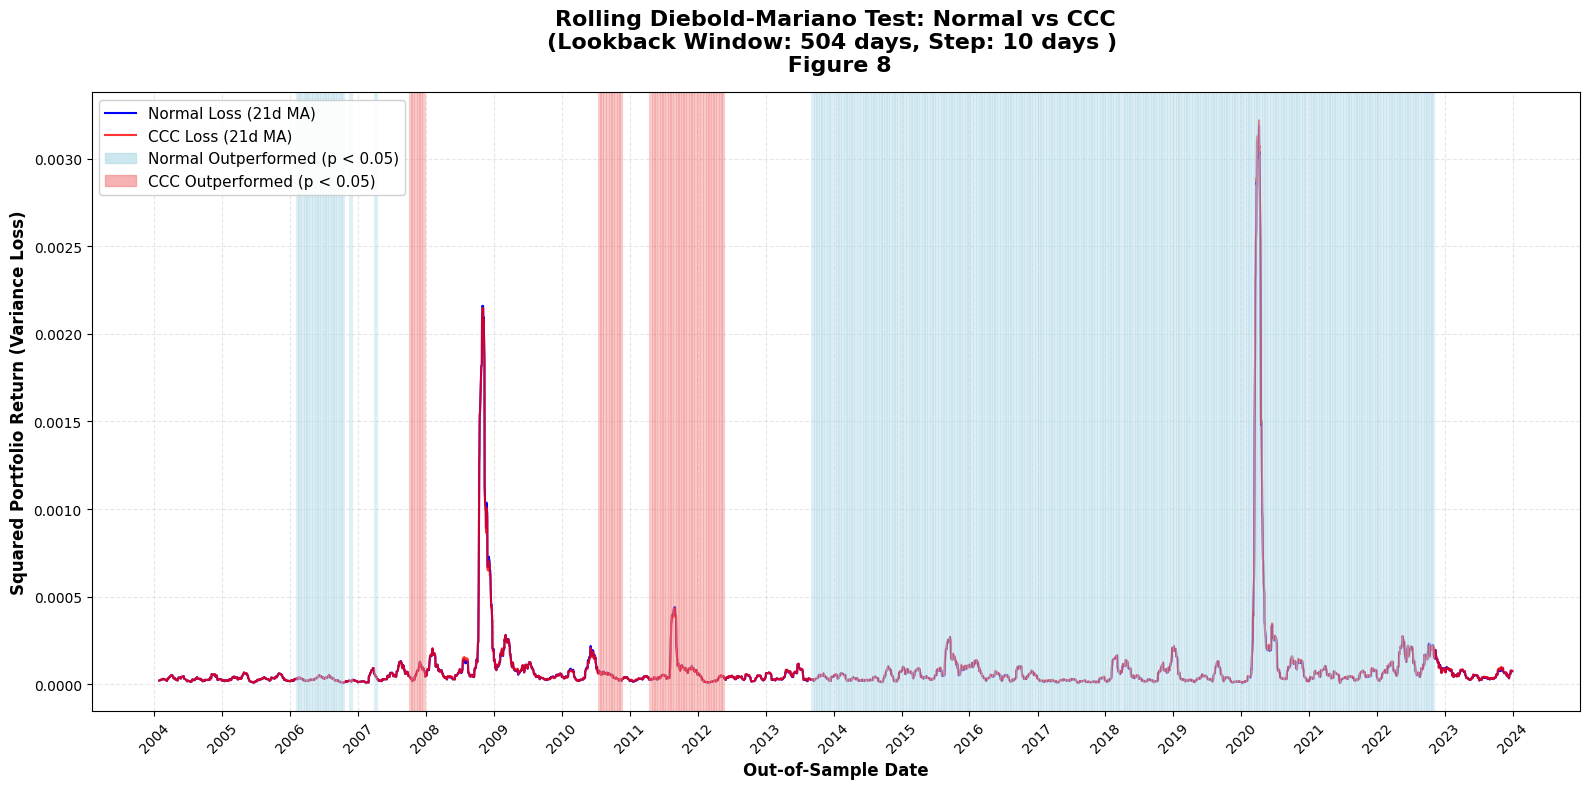

In [ ]:
# @title 📈 Normal vs CCC

plot_rolling_dm_test(loss_model = loss['EGARCH-Normal'], loss_base = loss['CCC'],
                     window_days=504, step=10, model_name = "Normal Copula", base_name = "CCC",
                     figure_num = 8)


The 2020 Crisis (The V-Shaped Recovery)
Figure 9 reveals that during the 2020 crisis, the Gumbel Copula performed significantly better than the Normal Copula. The Gumbel Copula assigns greater probability mass to the right tail (upper-tail dependence), meaning it is highly sensitive to joint market rallies. Because the 2020 crash was characterized by a sharp "V shaped" trajectory followed immediately by a massive, highly correlated market recovery, the Gumbel Copula successfully captured the joint upward movements better than symmetric models.

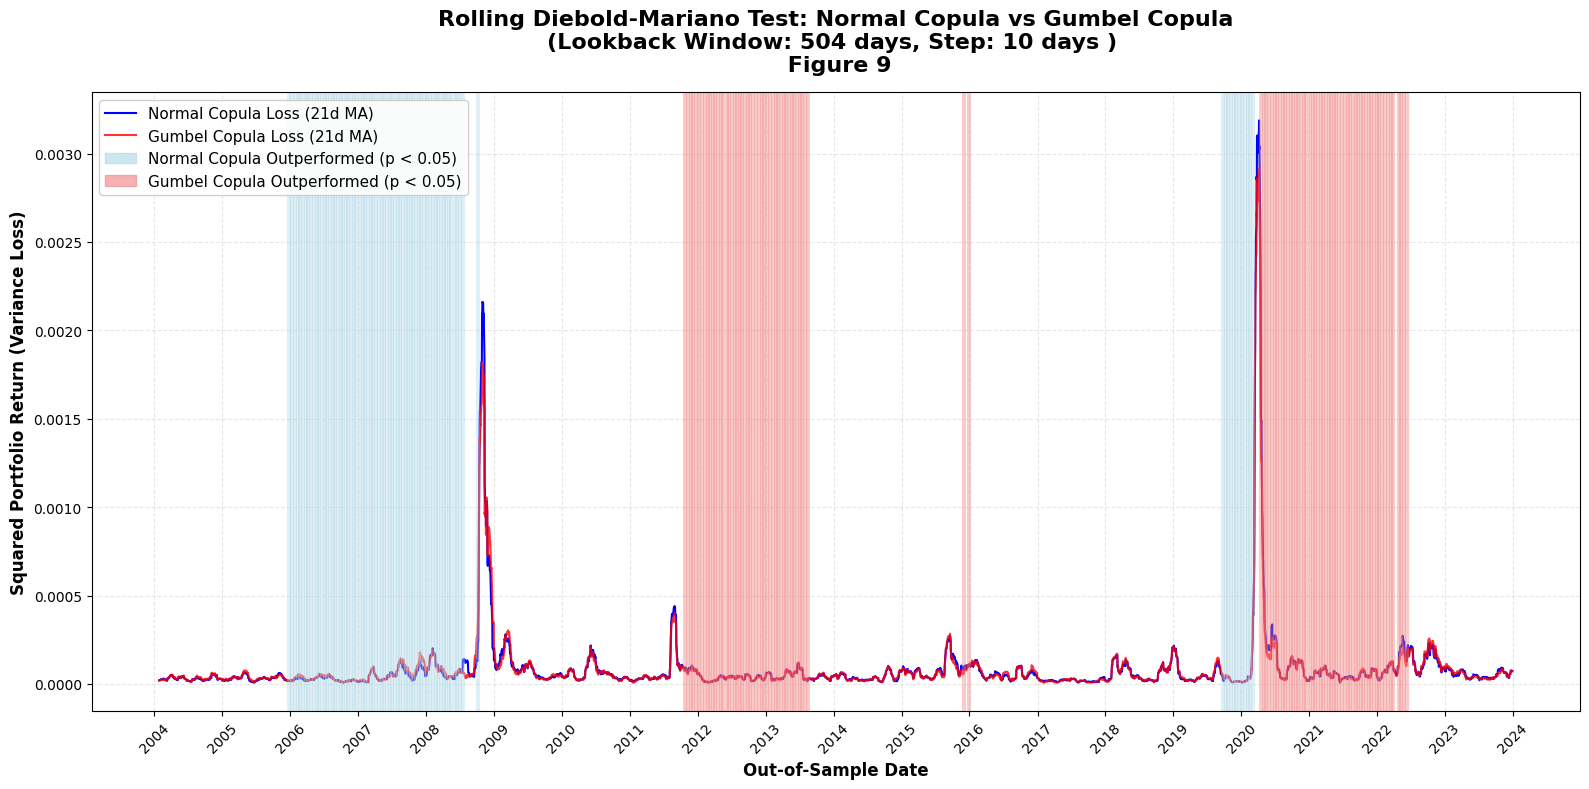

In [ ]:
# @title 📈 Normal vs Gumbel
plot_rolling_dm_test(loss_model =loss['EGARCH-Normal'] , loss_base = loss['EGARCH-Gumbel'], window_days=504,
                     step=10, model_name = "Normal Copula", base_name = "Gumbel Copula" , figure_num = 9)


The Pre-2008 Period (Estimation Noise)
Focusing on the lead-up to the 2008 Global Financial Crisis (2006 to mid-2008), both the Gumbel (Figure 10) and Clayton (Figure 11) Copulas performed worse than the CCC benchmark. During this low-volatility bull market, extreme tail events were rare. Consequently, applying highly complex asymmetric tail models introduced unnecessary estimation noise without providing tangible diversification benefits.

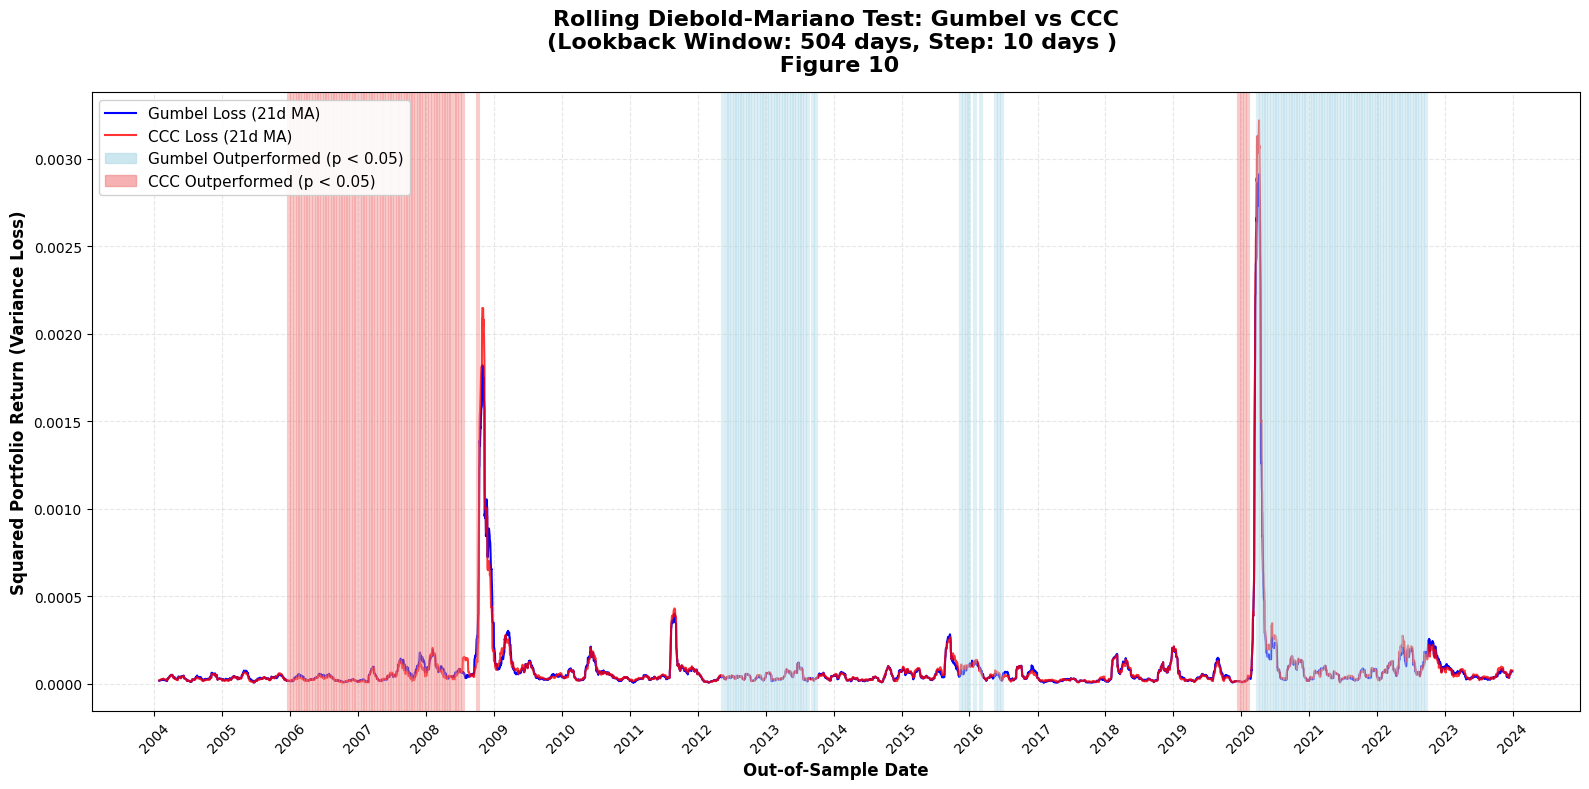

In [ ]:
# @title 📈 Gumbel vs CCC
plot_rolling_dm_test(loss_model = loss['EGARCH-Gumbel'], loss_base = loss['CCC'], window_days=504,
                     step=10, model_name = "Gumbel", base_name = "CCC" , figure_num = 10)


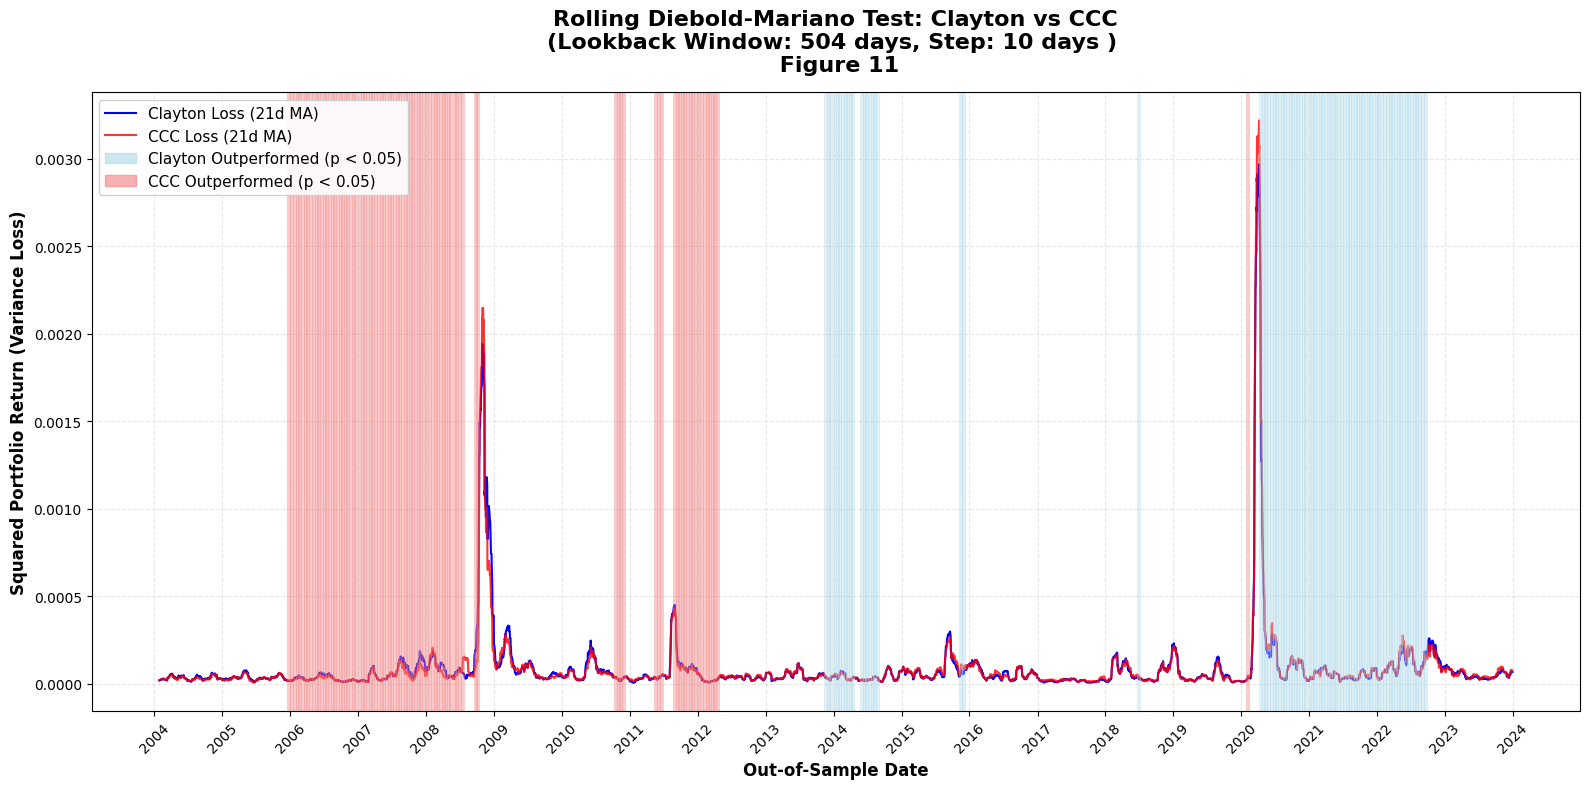

In [ ]:
# @title 📈 Clayton Vs CCC

plot_rolling_dm_test(loss_model = loss['EGARCH-Clayton'], loss_base = loss['CCC'],
                     window_days=504, step=10, model_name = "Clayton", base_name = "CCC",
                     figure_num = 11)


The 2008 Crash (The Short Selling Paradox)
A particularly interesting dynamic emerges when comparing the Standard Gumbel to the Rotated Gumbel during the actual 2008 crash. Mathematically, the Rotated Gumbel is an inverted distribution designed specifically to capture lower tail dependence (joint market crashes).

However, Figure 12 reveals a paradox: from the beginning of the 2008 crash, the Standard Gumbel actually outperformed the Rotated Gumbel when short-selling trades were permitted. Because the Standard Gumbel is computationally "blind" to left tail crash correlation, it severely underestimated the joint downward movement of the assets. This mathematical "flaw" serendipitously acted as a regularizer. It prevented the Markowitz optimizer from seeing near perfect correlations and taking on massive, highly leveraged short positions. By keeping the correlation matrix flatter, the Standard Gumbel forced the portfolio into a much more conservative, robust allocation that ultimately preserved capital better than the "correct" Rotated Gumbel model. Figure 13 comparing the Gumbel and rotated Gumbel model which just the long traids is alowed. The Rotated Guble works better in this condition.

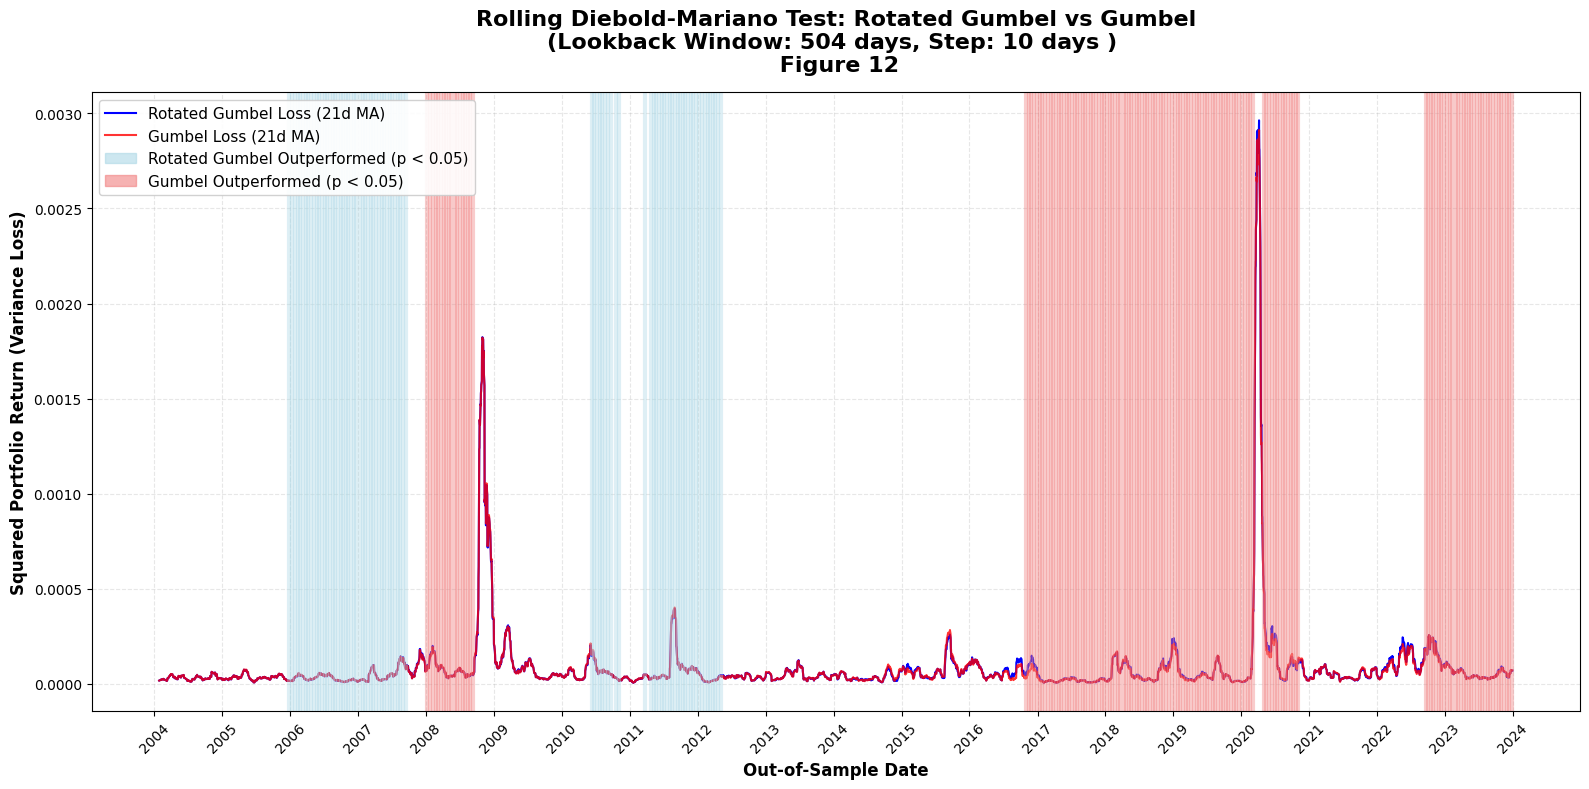

In [ ]:
# @title 📈 Rotated Gumbel Vs Gumbel
#def plot_rolling_dm_test(loss_model, loss_base, window_days=504, step=10, model_name="Test Model", base_name="Baseline")
plot_rolling_dm_test(loss_model = loss['EGARCH-Rotated-Gumbel'], loss_base = loss['EGARCH-Gumbel'],
                     window_days=504, step=10, model_name = "Rotated Gumbel", base_name = "Gumbel" ,
                     figure_num = 12)


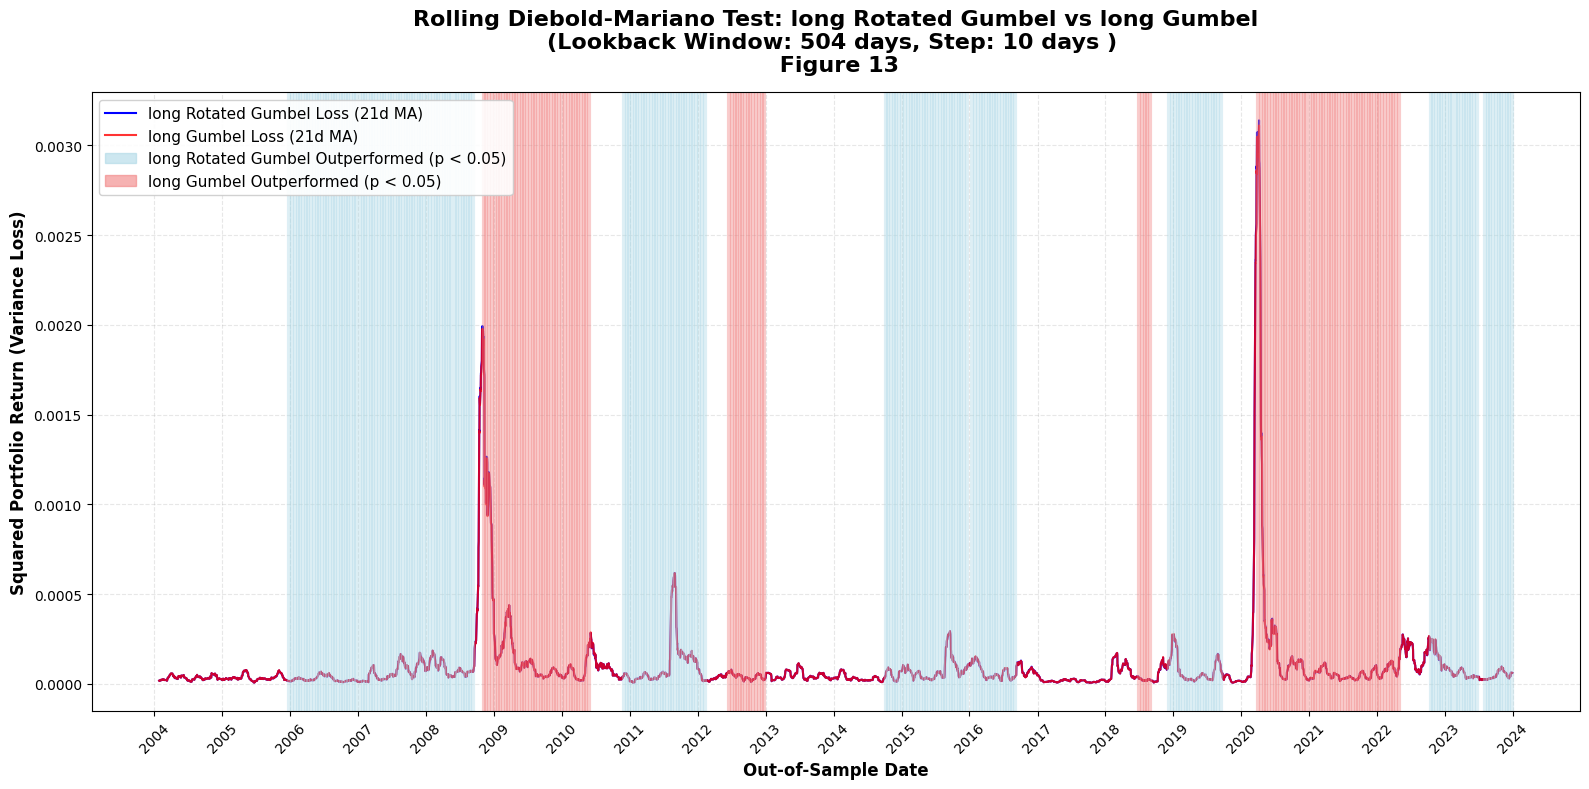

In [ ]:
# @title 📈 Rotated Gumbel Vs Gumbel Long
#def plot_rolling_dm_test(loss_model, loss_base, window_days=504, step=10, model_name="Test Model", base_name="Baseline")
plot_rolling_dm_test(loss_model = loss['EGARCH-Rotated-Gumbel-long'], loss_base = loss['EGARCH-Gumbel-long'],
                     window_days=504, step=10, model_name = "long Rotated Gumbel", base_name = "long Gumbel" ,
                     figure_num = 13)


# Discussion
The empirical findings of this study reinforce the central tenet of modern econometric forecasting: there is no universally superior model, only models that are distinctly calibrated to specific market regimes. The dynamic Diebold-Mariano evaluation reveals several critical insights regarding the practical implementation of Copula-GARCH models in portfolio optimization.
Firstly, the performance of asymmetric copulas is highly regime dependent. The significant outperformance of the Standard Gumbel copula during the 2020 COVID-19 crisis highlights the necessity of upper tail dependence modeling during periods characterized by sudden, V shaped recoveries and liquidity driven rallies. Conversely, applying complex asymmetric models during prolonged, low volatility bull markets (such as 2006–2008) introduces unnecessary parameter estimation noise, causing advanced copulas to underperform simpler benchmarks.

Secondly, this study uncovers a critical interaction between copula tail dependence, optimization constraints, and estimation error. Theoretical mathematics dictates that the Rotated Gumbel copula which explicitly models joint market crashes (lower tail dependence) should strictly dominate during the 2008 Global Financial Crisis. However, our empirical results demonstrate the opposite: the mathematically "blind" Standard Gumbel copula minimized portfolio variance more effectively when short selling was permitted. This paradox occurs because Mean-Variance optimizers function as "estimation error maximizers." When the Rotated Gumbel correctly identifies near-perfect asset correlations during a crash, the unconstrained Markowitz optimizer interprets this as an arbitrage opportunity, resulting in highly leveraged, opposing long/short positions. When real world correlations inevitably deviate from these extreme estimates, these leveraged positions trigger massive portfolio variance. The Standard Gumbel, by underestimating downside correlation, serendipitously acted as a mathematical regularizer, forcing the optimizer into a flatter, more conservative allocation.

Model Failure as a Diagnostic Tool Finally, this research suggests a novel application for quantitative frameworks. Rather than strictly viewing model failure as a deficiency, the differential performance of these copulas can be utilized as a diagnostic barometer for hidden market conditions. Because each copula family is mathematically highly specialized Clayton for left tail crashes, Gumbel for right tail rallies, and Normal for standard elliptical behavior tracking which model is currently passing or failing the rolling Diebold Mariano test allows researchers to instantly identify the prevailing market regime. In this way, deploying a diverse suite of Copula-GARCH models serves not just as an optimization technique, but as an active, real time investigative tool to decode the structural reality of the financial markets.


# Refrence

* Andrew J. Patton Copula Methods for Forecasting Multivariate Time Series 2012
* Jae, Harry. Dependence modeling with copula 2015
* Data source:
  
  https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_10_ind_port.html

